In [ ]:
using Revise
includet("functions.jl")
#includet("Julia/NHQRM/functions.jl")
using .MyFunctions

using LinearAlgebra
using QuantumToolbox
using ProgressMeter
using CairoMakie
# import Pkg
# Pkg.activate(".")

CairoMakie.activate!(type = "png", px_per_unit = 2)

set_theme!(merge(theme_latexfonts(),
    Theme(
        size           = (800, 500),
        fontsize       = 20,
        figure_padding = 14,
        Axis = (
            xgridvisible = false,
            ygridvisible = false,
            xtickalign   = 0,
            ytickalign   = 0,
            xlabelsize     = 24,
            ylabelsize     = 24,
            xticklabelsize = 20,
            yticklabelsize = 20,
        ),
        Lines = (linewidth = 3,),
    ),
))

# Hermitian case

In [2]:
ωa = 1.0
ωb = 1.0
Nc = 20
N = 1

vars = (ωa=ωa, ωb=ωb, Nc=Nc, N=N);

In [3]:
g_list = range(1e-3, 1.5, 600) |> collect

neigs = 40

vals_full = similar(g_list, length(g_list), neigs)
fill!(vals_full, NaN)

Prog = Progress(length(g_list))
@time Threads.@threads for i in eachindex(g_list)
    vals_full[i,:] = get_shifted_eigvals(H_Dicke(g_list[i], vars), neigs, -1000, 1e-16)
    next!(Prog)
end

nel = 4    # eigenvalues kept per block, (N+3-2*j)*nel
nj = Int64(floor(N/2+1))
neigs = [Int64((N+1-2*i)*nel) for i in 0:nj-1]
vals_sep = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_sep, NaN)

H_0_sep, H_int_sep = H_comp_separated(vars)
@time Threads.@threads for i in eachindex(g_list)
    H_Dicke = H_Dicke_separated(H_0_sep, H_int_sep, g_list[i])
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_sep[j,i,1:neigs_j] .= real.(prov.values)
    end
end

vals_polaron = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_polaron, NaN)

@time Threads.@threads for i in eachindex(g_list)
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke_polaron(g_list[i], vars)[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_polaron[j,i,1:neigs_j] .= real.(prov.values)
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:12


 12.778846 seconds (57.57 M allocations: 3.832 GiB, 8.87% gc time, 139 lock conflicts, 3025.67% compilation time: <1% of which was recompilation)
  0.297217 seconds (975.48 k allocations: 561.262 MiB, 30.32% gc time, 1136.95% compilation time)
  3.126934 seconds (16.23 M allocations: 1.575 GiB, 7.34% gc time, 2929.78% compilation time)


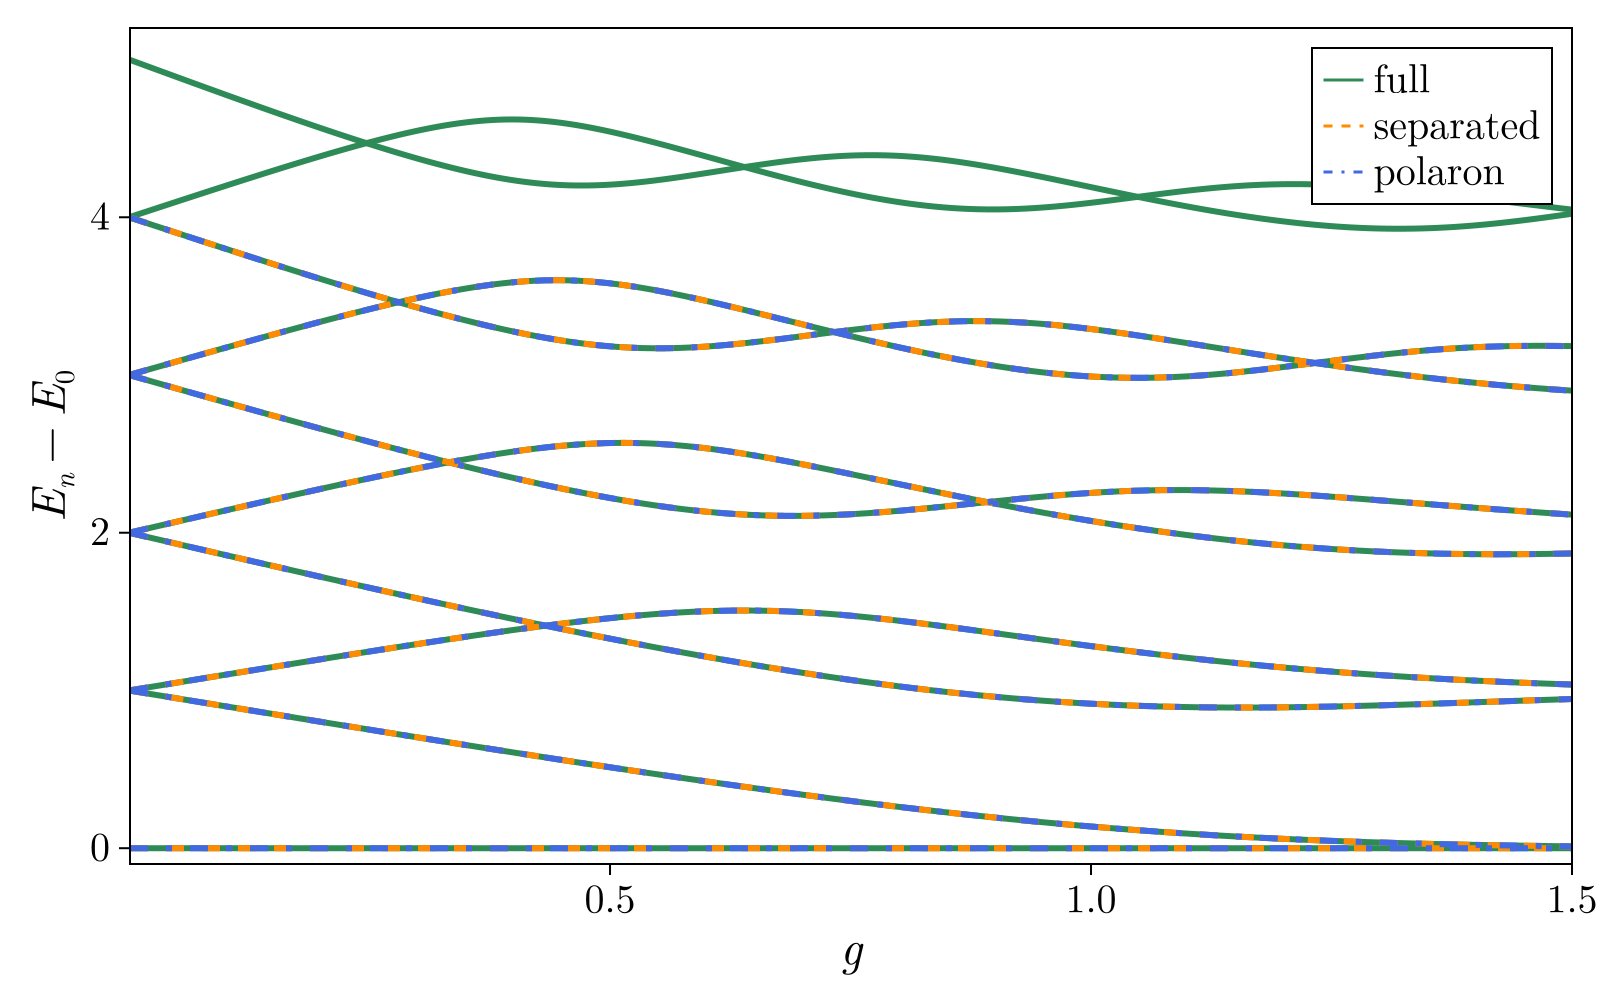

In [4]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel = L"g", ylabel = L"E_n - E_0", limits = ((g_list[1], g_list[end]), (-0.1, 5.2)))

for i in 1:10
    lines!(ax, g_list, vals_full[:, i]; color = :seagreen)
end

for i in 1:nj
    for k in axes(vals_sep, 3)
        lines!(ax, g_list, vals_sep[i, :, k] .- vals_sep[1, :, 1]; color = :darkorange, linestyle = :dash)
    end
    for k in axes(vals_polaron, 3)
        lines!(ax, g_list, vals_polaron[i, :, k] .- vals_polaron[1, :, 1]; color = :royalblue, linestyle = :dashdot)
    end
end

Legend(fig[1, 1],
    [LineElement(color = :seagreen),
     LineElement(color = :darkorange, linestyle = :dash),
     LineElement(color = :royalblue, linestyle = :dashdot)],
    ["full", "separated", "polaron"];
    tellwidth = false, tellheight = false,
    halign = :right, valign = :top, margin = (10, 10, 10, 10)
)

# save("QRM_energies_1at.pdf", fig; px_per_unit = 3)
fig

# Non-Hermitian case

This case works only when the coupling strengths between the qubit and oscillator, as well as between the system and the external environment are weak. In particular, by neglecting the quantum jumps, we obtain the non-Hermitian Hamiltonian generating the post-selected evolution.

In [12]:
P_NH = (g = 1.0, ωa = 1.0, ωb = 1.0, Nc = 80, N = 1, γa = 0.0, γb = 0.0)

_vars(p) = (ωa = p.ωa, ωb = p.ωb, Nc = p.Nc, N = p.N, γa = p.γa, γb = p.γb)
nh_block(p, wh) = (r = parity_blocks_NH(p.g, _vars(p)); wh === :even ? r[1] : r[2])
withp(p; kw...) = merge(p, (; kw...))
set2(p, k1, x1, k2, x2) = merge(p, NamedTuple{(k1, k2)}((x1, x2)))

function pair_gap_overlap(H; kmax = 10)
    F = eigen(H)
    idx = sortperm(real.(F.values))
    vals = F.values[idx]
    vecs = F.vectors[:, idx]
    
    k = min(kmax, length(vals))
    m = Inf
    pa = 0
    pb = 0
    for a in 1:k, b in a+1:k
        d = abs(vals[a] - vals[b])
        d < m && (m = d; pa = a; pb = b)
    end
    return m, abs(dot(vecs[:, pa], vecs[:, pb])) / (norm(vecs[:, pa]) * norm(vecs[:, pb]))
end

function closest_pair(p, wh; kmax = 10)
    v = sort(eigvals(nh_block(p, wh)), by = real)

    k = min(kmax, length(v))
    m = Inf
    pa = 0
    pb = 0
    for a in 1:k, b in a+1:k
        d = abs(v[a] - v[b])
        d < m && (m = d; pa = a; pb = b)
    end
    return pa, pb
end

d2_pair(p, k1, k2, x1, x2, wh, pa, pb) = (v = sort(eigvals(nh_block(set2(p, k1, x1, k2, x2), wh)), by = real); (v[pa] - v[pb])^2)

function newton_ep(p, k1, k2, wh, pa, pb; iters = 60, step = 1e-6)
    x = [getfield(p, k1), getfield(p, k2)]
    for _ in 1:iters
        f  = d2_pair(p, k1, k2, x[1], x[2], wh, pa, pb)
        f1 = (d2_pair(p, k1, k2, x[1]+step, x[2], wh, pa, pb) - f) / step
        f2 = (d2_pair(p, k1, k2, x[1], x[2]+step, wh, pa, pb) - f) / step
        dx = [real(f1) real(f2); imag(f1) imag(f2)] \ [-real(f); -imag(f)]
        s  = min(1.0, 0.3 / (norm(dx) + step^2))
        x .+= s .* dx
        x[1] = clamp(x[1], 0.0, 3.0); x[2] = clamp(x[2], 0.0, 3.0)
        norm(s .* dx) < 1e-13 && break
    end
    return set2(p, k1, x[1], k2, x[2])
end

function ep_check(p, wh, pa, pb)
    F = eigen(nh_block(p, wh))
    idx = sortperm(real.(F.values))
    vals = F.values[idx]
    vecs = F.vectors[:, idx]
    gap = abs(vals[pa] - vals[pb])
    ov  = abs(dot(vecs[:, pa], vecs[:, pb])) / (norm(vecs[:, pa]) * norm(vecs[:, pb]))
    return gap, ov
end

ep_check (generic function with 1 method)

## Presence of EPs varying $g$ and $\gamma_a$ ($\gamma_b = 0$)

We study the presence of EPs by firstly scanning a 2D colormap, and subsequently (sitting on a specific EP) the energy levels and eigenvectors. We notice that, even if the parameters should change between EPs, it is possible to see almost all the EPs on the energy spectrum, since they are localed almost on the line $\gamma_a =$ cost. All the EPs found in the USC are most likely artifacts. Nonetheless, genuine EPs can be found in the weak coupling regime corresponding to the transition between weak and strong coupling.

In [22]:
gs = range(0.2, 1.5, 200) |> collect
γs = range(0.05, 1.0, 200) |> collect

GAP = fill(Inf, length(gs), length(γs))
OVL = zeros(length(gs), length(γs))
PAR = fill(:even, length(gs), length(γs))

Prog = Progress(length(gs))
Threads.@threads for i in eachindex(gs)
    for j in eachindex(γs)
        g = gs[i]
        γa = γs[j]
        He, Ho = parity_blocks_NH(g, _vars(withp(P_NH; g = g, γa = γa)))
        me, oe = pair_gap_overlap(He)
        mo, oo = pair_gap_overlap(Ho)
        if me <= mo
            GAP[i, j] = me
            OVL[i, j] = oe
            PAR[i, j] = :even
        else
            GAP[i, j] = mo
            OVL[i, j] = oo
            PAR[i, j] = :odd
        end
    end
    next!(Prog)
end

eps_found = NamedTuple[]
Prog = Progress(length(gs) - 2)
Threads.@threads for i in 2:length(gs)-1
    for j in 2:length(γs)-1
        if all(GAP[i, j] <= GAP[i+di, j+dj] for di in -1:1, dj in -1:1)
            wh = PAR[i, j]
            pseed = withp(P_NH; g = gs[i], γa = γs[j])
            pa, pb = closest_pair(pseed, wh)
            pe = newton_ep(pseed, :g, :γa, wh, pa, pb)
            gap, ov = ep_check(pe, wh, pa, pb)
            if gap < 1e-5 && ov > 1 - 1e-6
                e = (g = round(pe.g, digits = 4), γa = round(pe.γa, digits = 4), parity = wh, gap = gap, ov = ov, energy_levels = (pa, pb))
                any(u -> abs(u.g - e.g) < 1e-2 && abs(u.γa - e.γa) < 1e-2, eps_found) || push!(eps_found, e)
            end
        end
    end
    next!(Prog)
end

println("exact EPs found (γb = $(P_NH.γb)): ", length(eps_found))
foreach(e -> println("  g = ", e.g, "   γa = ", e.γa, "   ", e.parity, "   ", e.energy_levels, "   gap = ", round(e.gap, sigdigits = 2), "   1-overlap = ", round(1 - e.ov, sigdigits = 2)), eps_found)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:37
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


exact EPs found (γb = 0.0): 22
  g = 0.4361   γa = 0.5835   odd   (6, 7)   gap = 2.8e-7   1-overlap = 7.0e-14
  g = 0.3552   γa = 0.5832   even   (9, 10)   gap = 2.8e-7   1-overlap = 7.1e-14
  g = 1.1049   γa = 0.3272   odd   (6, 7)   gap = 1.8e-7   1-overlap = 1.7e-14
  g = 0.8411   γa = 0.4137   odd   (5, 6)   gap = 2.4e-7   1-overlap = 3.8e-14
  g = 0.5372   γa = 0.5843   odd   (4, 5)   gap = 1.7e-7   1-overlap = 2.5e-14
  g = 0.9542   γa = 0.4174   even   (4, 5)   gap = 1.8e-7   1-overlap = 2.0e-14
  g = 0.7027   γa = 0.4109   odd   (7, 8)   gap = 1.8e-7   1-overlap = 2.2e-14
  g = 0.4787   γa = 0.5838   even   (5, 6)   gap = 1.7e-7   1-overlap = 2.7e-14
  g = 1.2326   γa = 0.3323   even   (5, 6)   gap = 1.6e-7   1-overlap = 1.3e-14
  g = 1.3413   γa = 0.2745   odd   (7, 8)   gap = 3.0e-7   1-overlap = 4.0e-14
  g = 0.4033   γa = 0.5834   even   (7, 8)   gap = 6.2e-8   1-overlap = 3.4e-15
  g = 1.4786   γa = 0.2804   even   (6, 7)   gap = 2.5e-7   1-overlap = 2.6e-14
  g = 0.6555  

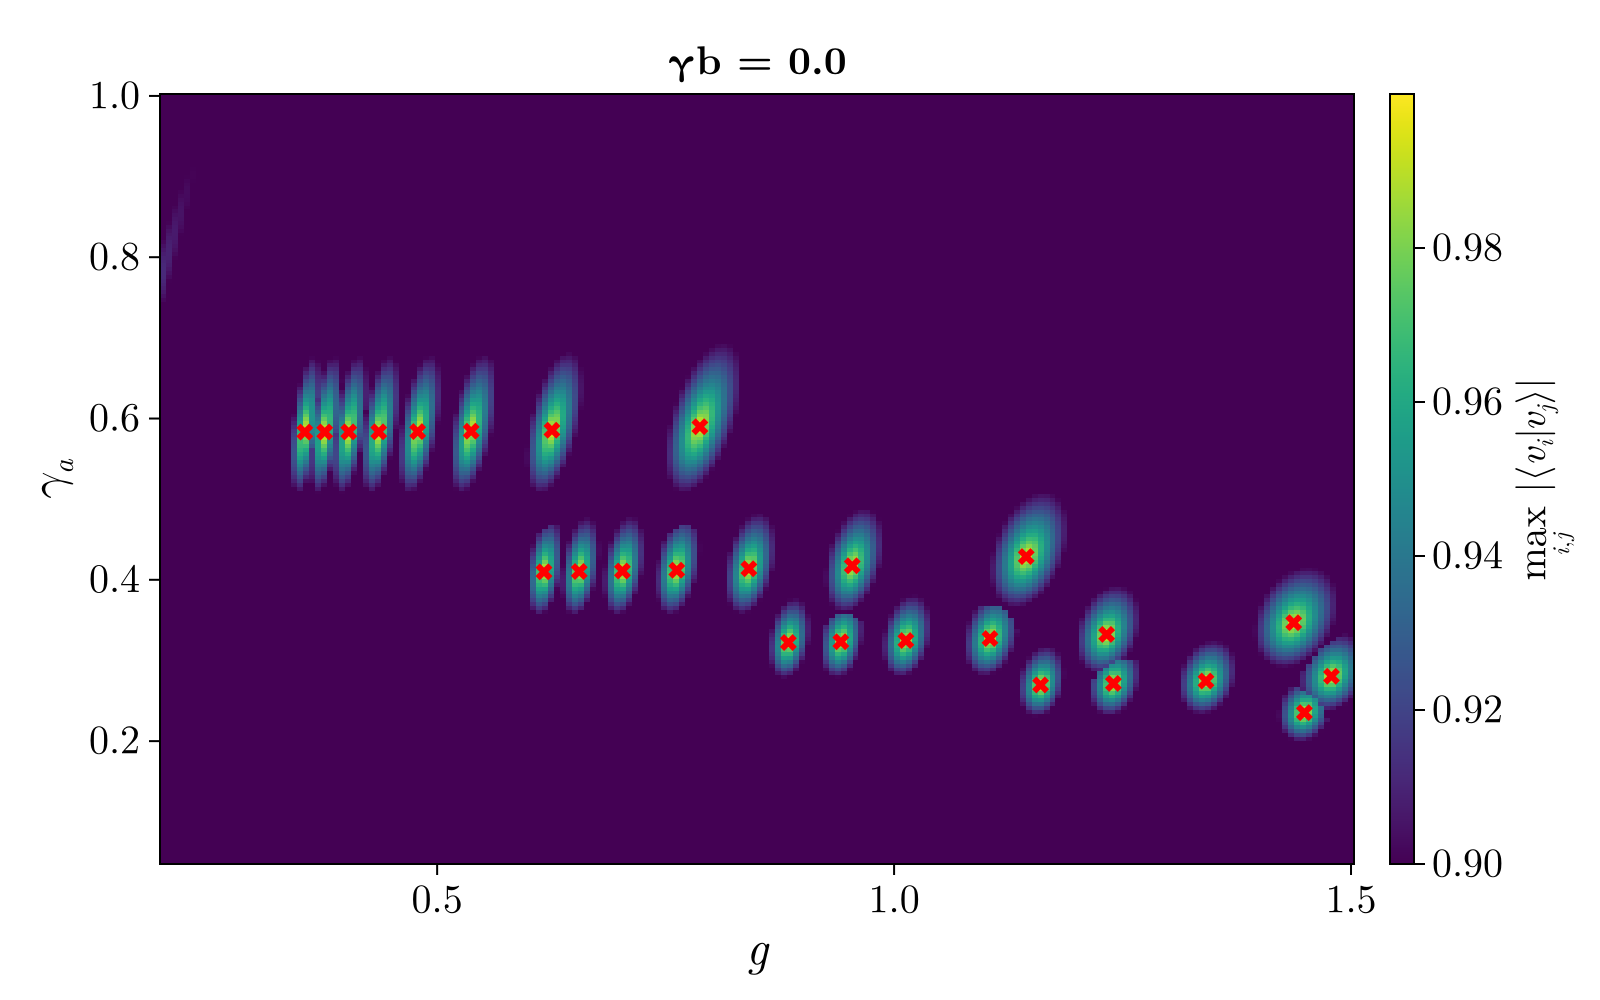

In [ ]:
fig_map = Figure(size = (800, 500))

ax = Axis(fig_map[1, 1]; xlabel = L"g", ylabel = L"\gamma_a", title = "γb = $(P_NH.γb)")
hm = heatmap!(ax, gs, γs, OVL; colormap = :viridis, colorrange = (0.9, 1.0))
Colorbar(fig_map[1, 2], hm; label = L"\max_{i,j}\,|\langle v_i|v_j\rangle|")
scatter!(ax, [e.g for e in eps_found], [e.γa for e in eps_found]; color = :red, marker = :xcross, markersize = 12)

# save("ep_map.png", fig_map; px_per_unit = 3)
fig_map

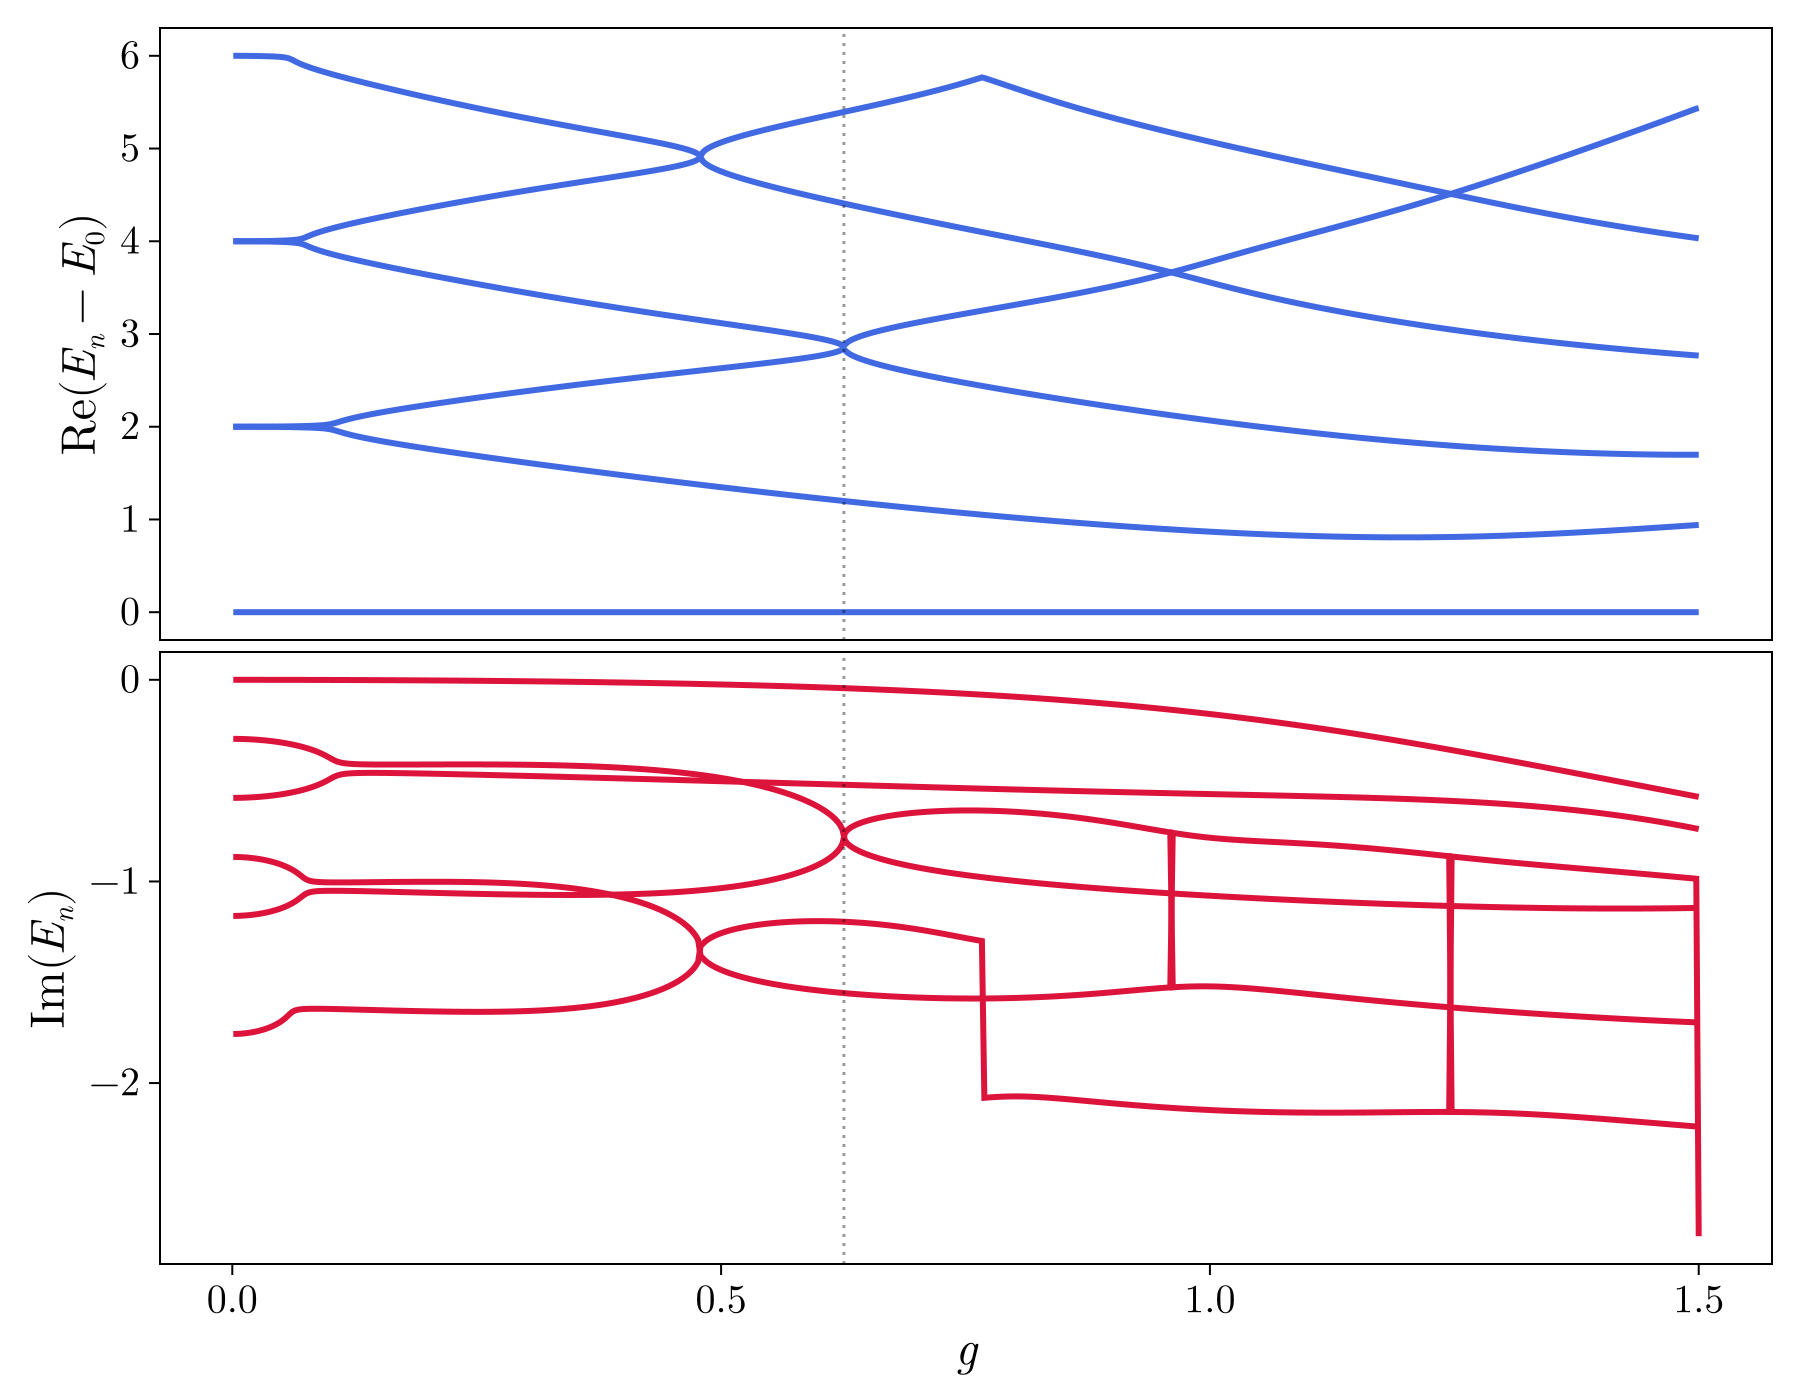

In [ ]:
ep  = eps_found[8]
pep = withp(P_NH; g = ep.g, γa = ep.γa)
g_list_cut  = range(ep.g - 0.15, ep.g + 0.15, 400) |> collect
pa, pb = ep.energy_levels
kshow = 6

Ecut = fill(NaN + 0im, length(g_list), kshow)
for (i, g) in enumerate(g_list)
    v = sort(eigvals(nh_block(withp(pep; g = g), ep.parity)), by = real)
    Ecut[i, :] = v[1:kshow] .- real(v[1])
end


fig_cut = Figure(size = (900, 700))

a1 = Axis(fig_cut[1, 1]; ylabel = L"\mathrm{Re}(E_n - E_0)")
for n in 1:kshow
    lines!(a1, g_list, real.(Ecut[:, n]); color = :royalblue)
end

a2 = Axis(fig_cut[2, 1]; xlabel = L"g", ylabel = L"\mathrm{Im}(E_n)")
for n in 1:kshow
    lines!(a2, g_list, imag.(Ecut[:, n]); color = :crimson)
end

hidexdecorations!(a1; grid = false)
linkxaxes!(a1, a2)
vlines!(a1, [ep.g]; color = (:black, 0.4), linestyle = :dot)
vlines!(a2, [ep.g]; color = (:black, 0.4), linestyle = :dot)

rowgap!(fig_cut.layout, 6)
# save("spectrum_cut_EP.png", fig_cut; px_per_unit = 3)
fig_cut

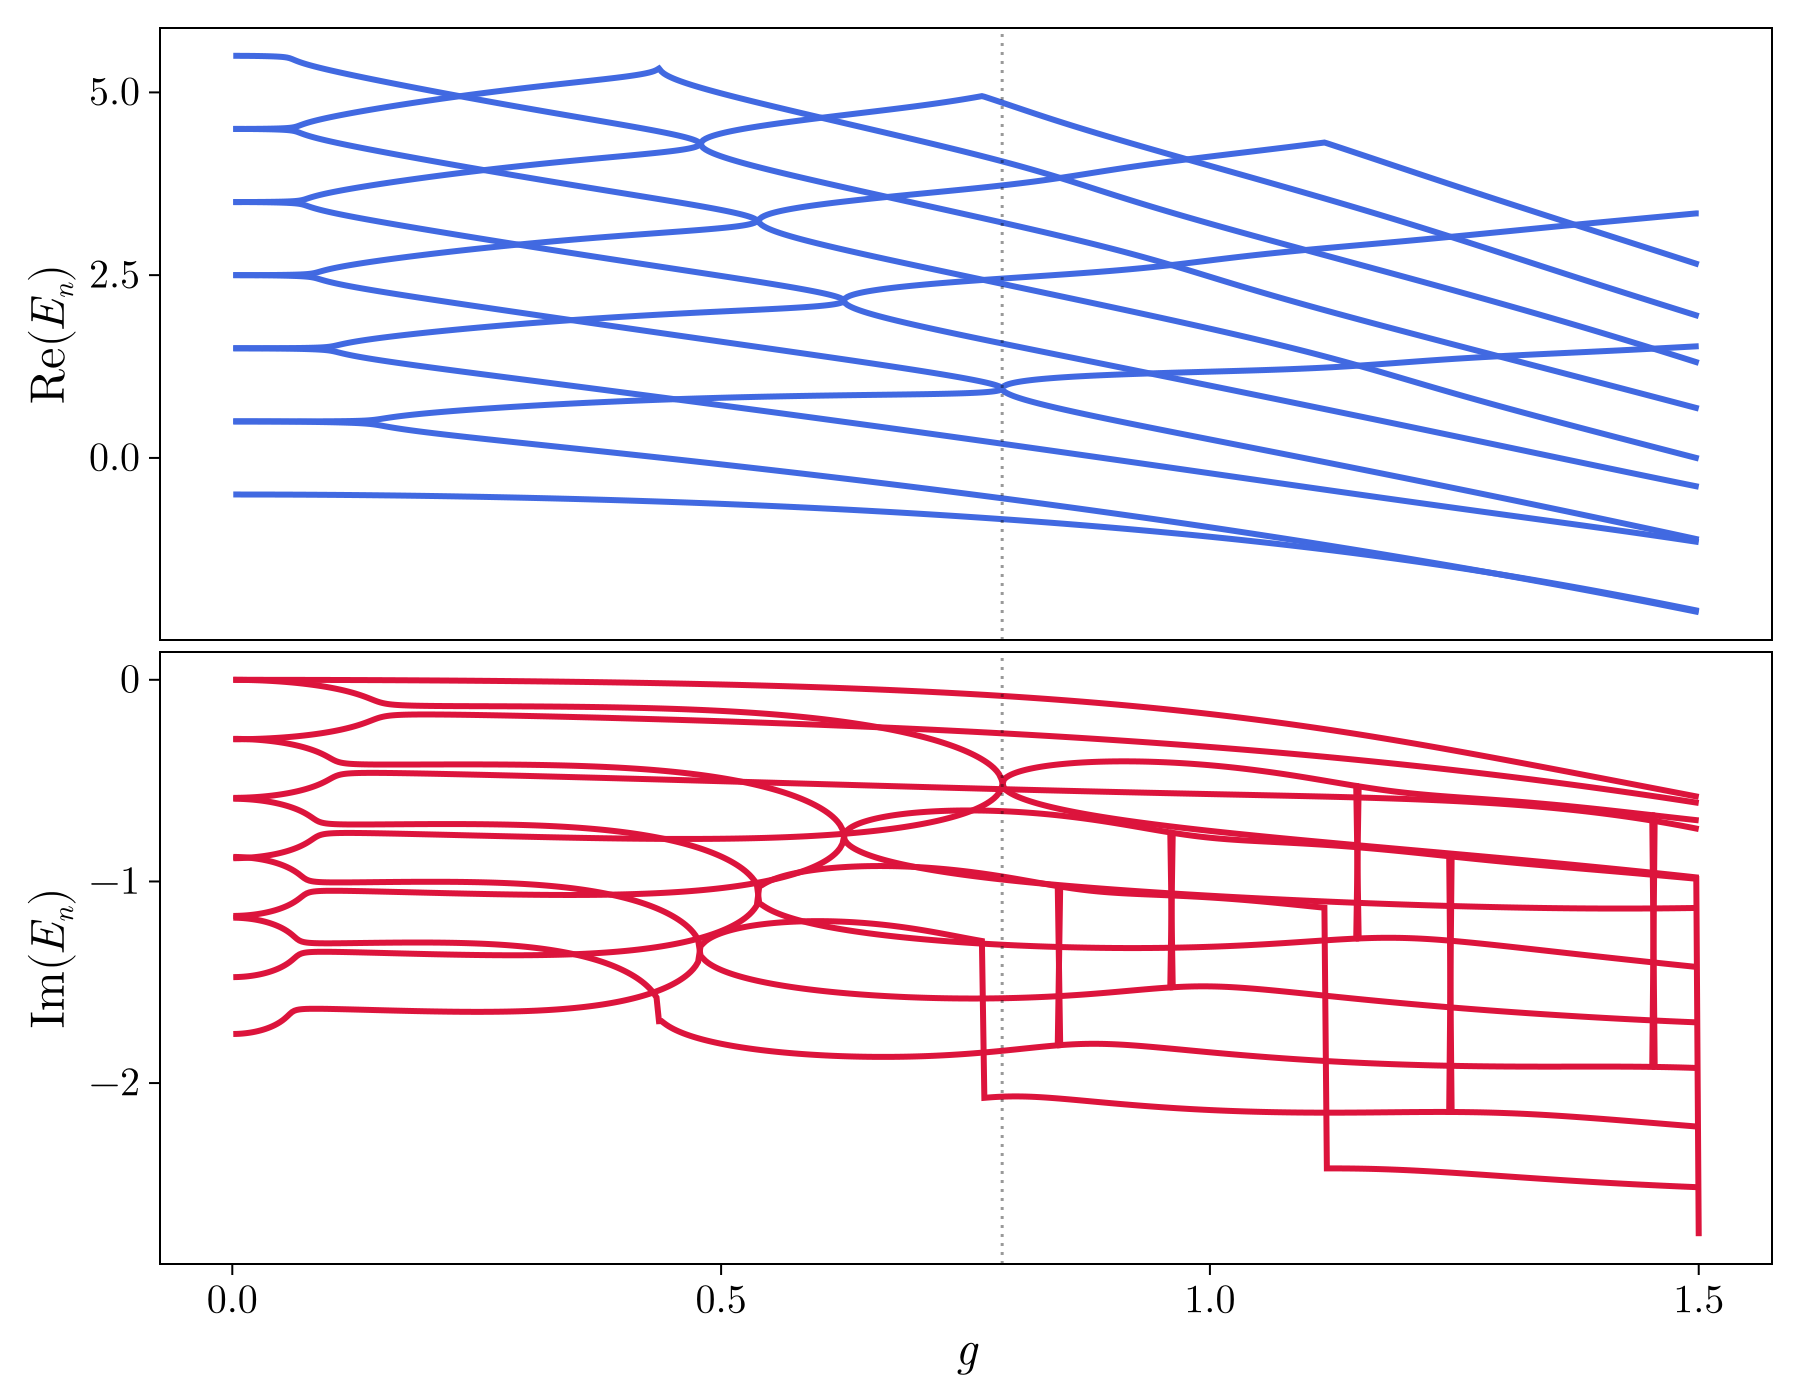

In [ ]:
ep  = eps_found[8]
pep = withp(P_NH; g = ep.g, γa = ep.γa)
g_list_cut  = range(ep.g - 0.15, ep.g + 0.15, 400) |> collect
pa, pb = ep.energy_levels
kshow = 6

Ecut = fill(NaN + 0im, length(g_list), kshow)
for (i, g) in enumerate(g_list)
    v = sort(eigvals(nh_block(withp(pep; g = g), ep.parity)), by = real)
    Ecut[i, :] = v[1:kshow]
end

fig_cut = Figure(size = (900, 700))
a1 = Axis(fig_cut[1, 1]; ylabel = L"\mathrm{Re}(E_n)")
for n in 1:kshow; lines!(a1, g_list, real.(Ecut[:, n]); color = :royalblue); end
hidexdecorations!(a1; grid = false)
a2 = Axis(fig_cut[2, 1]; xlabel = L"g", ylabel = L"\mathrm{Im}(E_n)")
for n in 1:kshow; lines!(a2, g_list, imag.(Ecut[:, n]); color = :crimson); end


ep  = eps_found[12]
pep = withp(P_NH; g = ep.g, γa = ep.γa)
g_list_cut  = range(ep.g - 0.15, ep.g + 0.15, 400) |> collect
pa, pb = ep.energy_levels
kshow = 6

Ecut = fill(NaN + 0im, length(g_list), kshow)
for (i, g) in enumerate(g_list)
    v = sort(eigvals(nh_block(withp(pep; g = g), ep.parity)), by = real)
    Ecut[i, :] = v[1:kshow]
end
for n in 1:kshow; lines!(a1, g_list, real.(Ecut[:, n]); color = :royalblue); end
for n in 1:kshow; lines!(a2, g_list, imag.(Ecut[:, n]); color = :crimson); end

linkxaxes!(a1, a2)
vlines!(a1, [ep.g]; color = (:black, 0.4), linestyle = :dot)
vlines!(a2, [ep.g]; color = (:black, 0.4), linestyle = :dot)

rowgap!(fig_cut.layout, 6)
# save("spectrum_cut_EP.png", fig_cut; px_per_unit = 3)
fig_cut

## Study of the impact of $\gamma_b$

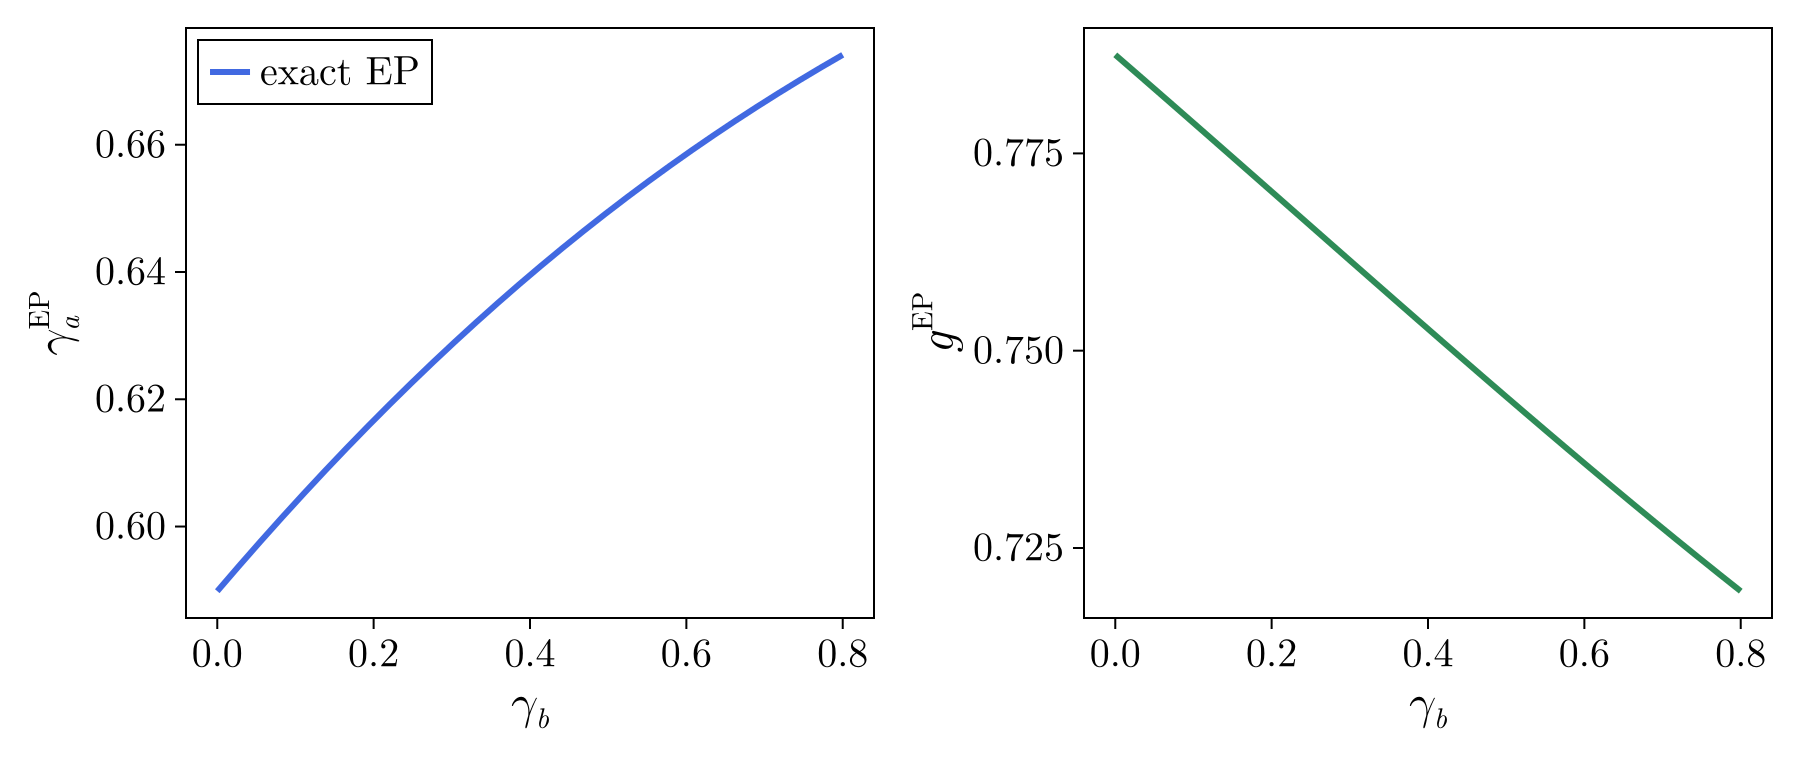

In [ ]:
ep = eps_found[12]
pa, pb = closest_pair(withp(P_NH; g = ep.g, γa = ep.γa), ep.parity)

γb_scan = range(0.0, 0.8, 30) |> collect
gEP  = similar(γb_scan)
γaEP = similar(γb_scan)

p = withp(P_NH; g = ep.g, γa = ep.γa)
for (i, γb) in enumerate(γb_scan)
    p = newton_ep(withp(p; γb = γb), :g, :γa, ep.parity, pa, pb)
    gEP[i] = p.g; γaEP[i] = p.γa
end

fig_γb = Figure(size = (900, 380))
axa = Axis(fig_γb[1, 1]; xlabel = L"\gamma_b", ylabel = L"\gamma_a^{\mathrm{EP}}")
lines!(axa, γb_scan, γaEP; color = :royalblue, label = "exact EP")
# lines!(axa, γb_scan, γaEP[1] .+ γb_scan; color = :crimson, linestyle = :dash, label = L"\gamma_a-\gamma_b=\mathrm{cost}\ (JC)")
axislegend(axa; position = :lt)
axg = Axis(fig_γb[1, 2]; xlabel = L"\gamma_b", ylabel = L"g^{\mathrm{EP}}")
lines!(axg, γb_scan, gEP; color = :seagreen)
save("ep_vs_gammab.png", fig_γb; px_per_unit = 3)
fig_γb

g = 0.7 : exact EPs on the (γa, γb) plane = 1
  γa = 0.4142   γb = 0.0592   odd   gap = 1.1e-7


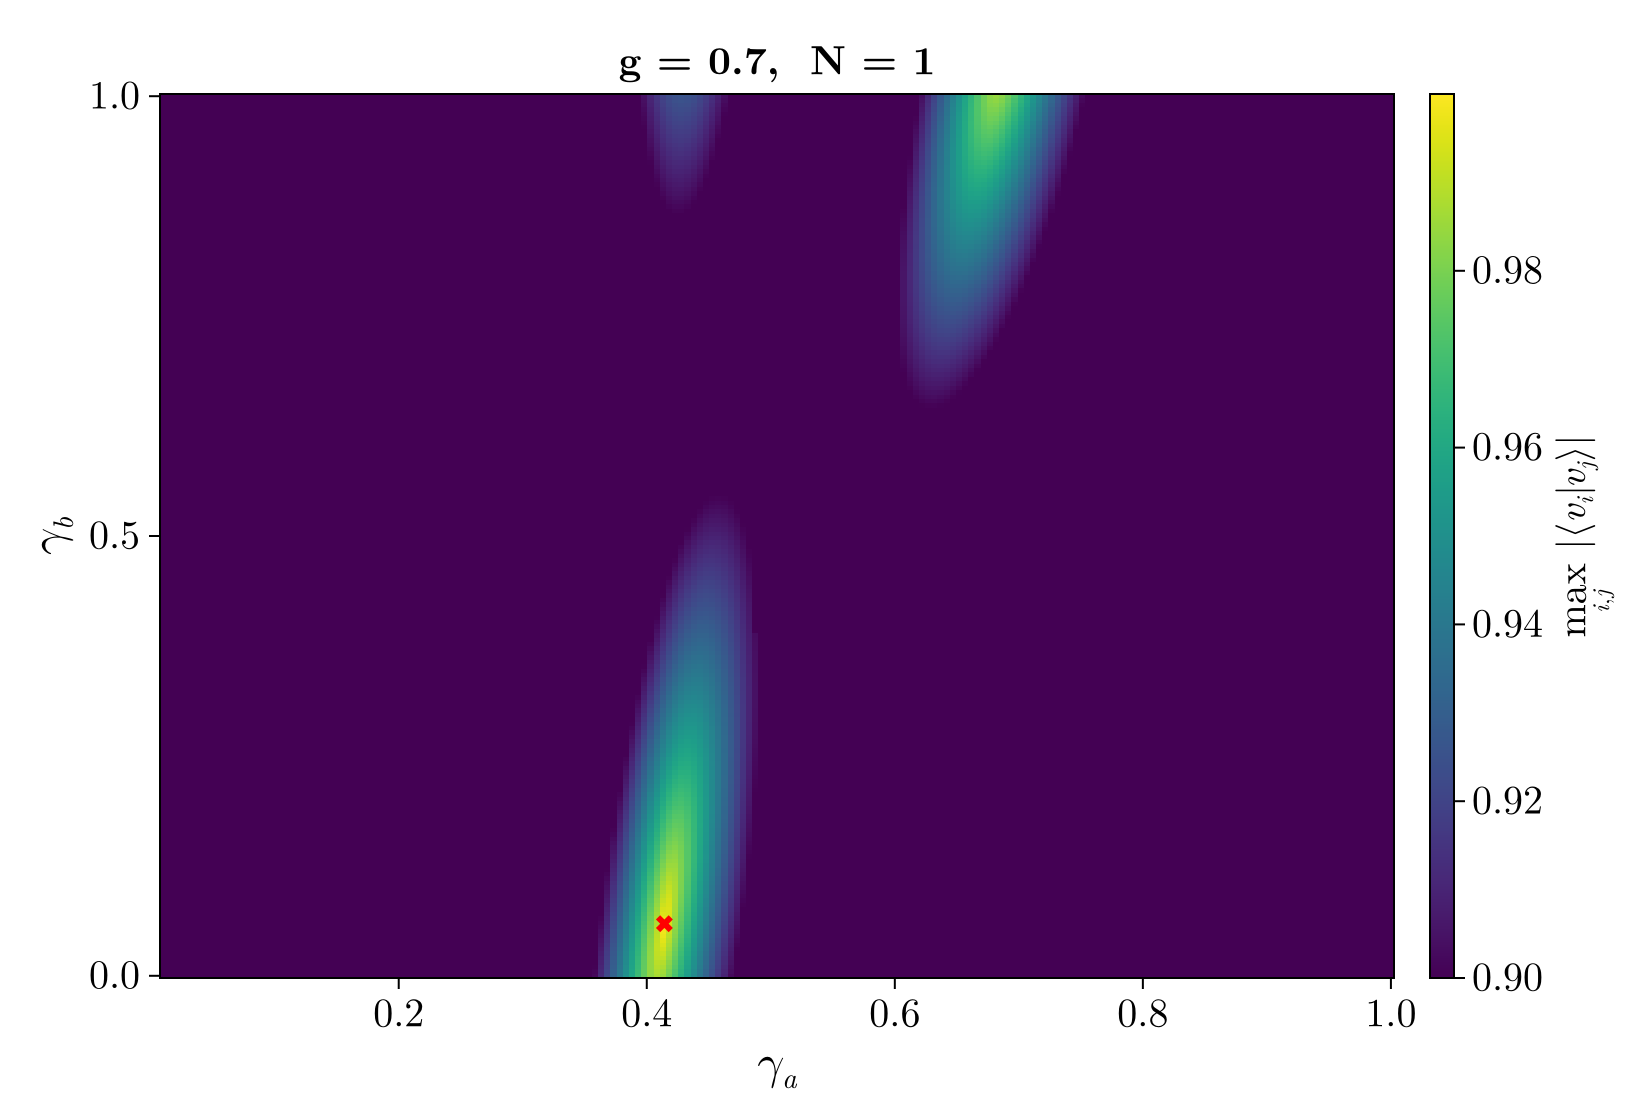

In [59]:
# Map exact EPs on the (γa, γb) plane at fixed g, tuning (:γa, :γb)
g_fix    = 0.7
γa_scan  = range(0.01, 1.0, 200) |> collect
γb_scan2 = range(0.0, 1.0, 200) |> collect

GAP2 = fill(Inf, length(γa_scan), length(γb_scan2))
OVL2 = zeros(length(γa_scan), length(γb_scan2))
PAR2 = fill(:even, length(γa_scan), length(γb_scan2))

for (i, γa) in enumerate(γa_scan), (j, γb) in enumerate(γb_scan2)
    He, Ho = parity_blocks_NH_coll(g_fix, _vars(withp(P_NH; g = g_fix, γa = γa, γb = γb)))
    me, oe = pair_gap_overlap(He)
    mo, oo = pair_gap_overlap(Ho)
    if me <= mo
        GAP2[i, j] = me
        OVL2[i, j] = oe
        PAR2[i, j] = :even
    else
        GAP2[i, j] = mo
        OVL2[i, j] = oo
        PAR2[i, j] = :odd
    end
end

eps_gab = NamedTuple[]
for i in 2:length(γa_scan)-1, j in 2:length(γb_scan2)-1
    if all(GAP2[i, j] <= GAP2[i+di, j+dj] for di in -1:1, dj in -1:1)   # 2D local minimum
        wh = PAR2[i, j]
        pseed = withp(P_NH; g = g_fix, γa = γa_scan[i], γb = γb_scan2[j])
        pa, pb = closest_pair(pseed, wh)
        pe = newton_ep(pseed, :γa, :γb, wh, pa, pb)
        gap, ov = ep_check(pe, wh, pa, pb)
        if gap < 1e-5 && ov > 1 - 1e-6 && pe.γa ≥ 0 && pe.γb ≥ 0
            e = (γa = round(pe.γa, digits = 4), γb = round(pe.γb, digits = 4), parity = wh, gap = gap, ov = ov)
            any(u -> abs(u.γa - e.γa) < 1e-2 && abs(u.γb - e.γb) < 1e-2, eps_gab) || push!(eps_gab, e)
        end
    end
end

println("g = $g_fix : exact EPs on the (γa, γb) plane = ", length(eps_gab))
foreach(e -> println("  γa = ", e.γa, "   γb = ", e.γb, "   ", e.parity, "   ", e.energy_levels, "   gap = ", round(e.gap, sigdigits = 2)), eps_gab)

fig_gab = Figure(size = (820, 560))
axm = Axis(fig_gab[1, 1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b", title = "g = $g_fix,  N = $(P_NH.N)")
hmg = heatmap!(axm, γa_scan, γb_scan2, OVL2; colormap = :viridis, colorrange = (0.9, 1.0))
Colorbar(fig_gab[1, 2], hmg; label = L"\max_{i,j}\,|\langle v_i|v_j\rangle|")
scatter!(axm, [e.γa for e in eps_gab], [e.γb for e in eps_gab]; color = :red, marker = :xcross, markersize = 12)
save("ep_map_gammas.png", fig_gab; px_per_unit = 3)
fig_gab

# Liouvillian case

## Emission spectrum

We use the emission spectrum to valide the energy levels and the system-bath coupling operators. The GME is used as with high filters to include the non-secular contributions. Low filters make the GME a dressed GKSL master equation, valid for weak system-bath couplings. For low intra-system couplings, it reduces to the standard Lindblad master equation.

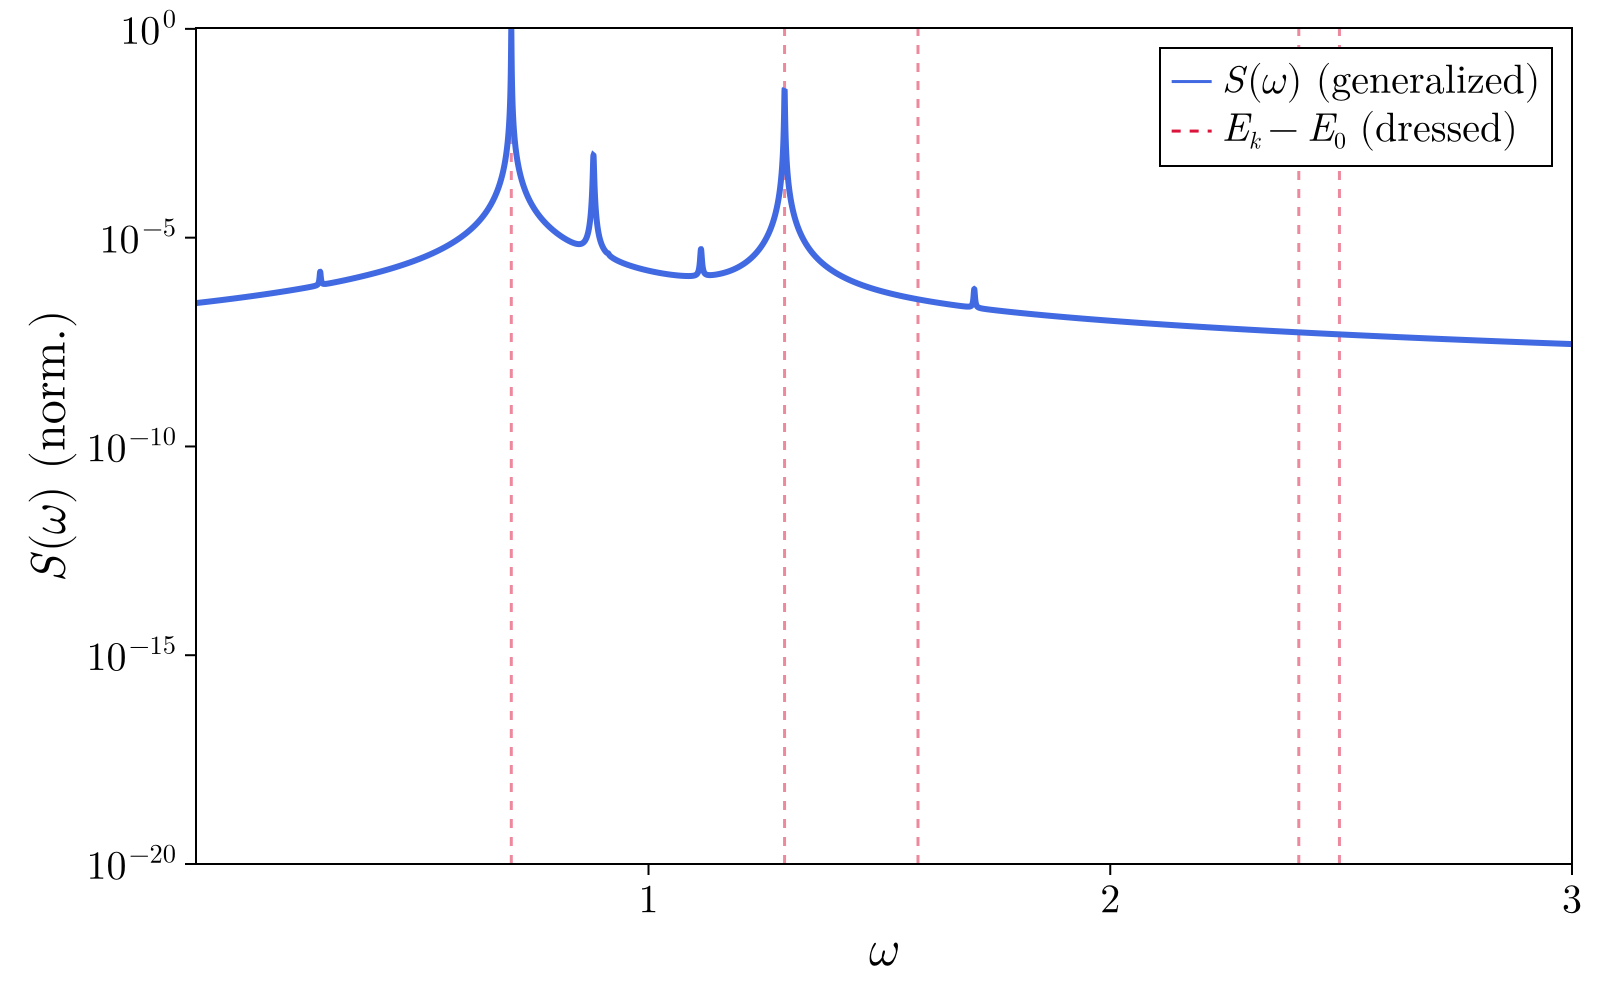

In [ ]:
vars_em = (ωa = 1.0, ωb = 1.0, Nc = 80, N = 1)
g_em, γ_em, T_em, NT_em = 0.3, 0.001, 0.15, 10

E_em, U_em, L_em = gen_liouvillian_qrm(g_em, vars_em, γ_em, T = [0.0, T_em], N_trunc = NT_em, σ_filter=0.1, tol=1e-12)

Ed = U_em.data' * qrm_emission_field(g_em, vars_em).data * U_em.data
Eplus = Qobj(triu(Ed, 1), dims=(NT_em,))

ω_em = range(0.02, 3.0, 50000) |> collect
S_em = spectrum(L_em, ω_em, nothing, Eplus', Eplus)
S_em ./= maximum(S_em)
S_plot = map(x -> x > 0 ? x : NaN, S_em)  

fig_em = Figure()
ax = Axis(fig_em[1, 1]; xlabel = L"\omega", ylabel = L"S(\omega)\ \mathrm{(norm.)}", limits = ((ω_em[1], ω_em[end]), (1e-20, 1.05)), yscale = log10)
for k in 2:min(8, length(E_em))
    vlines!(ax, [real(E_em[k] - E_em[1])]; color = (:crimson, 0.5), linestyle = :dash)
end
lines!(ax, ω_em, S_plot; color = :royalblue)

Legend(fig_em[1, 1], [LineElement(color = :royalblue), LineElement(color = :crimson, linestyle = :dash)], [L"S(\omega)\ \mathrm{(generalized)}", L"E_k - E_0\ \mathrm{(dressed)}"];
    tellwidth = false, tellheight = false, halign = :right, valign = :top, margin = (10, 10, 10, 10))

# save("emission_spectrum.png", fig_em; px_per_unit = 3)
fig_em

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


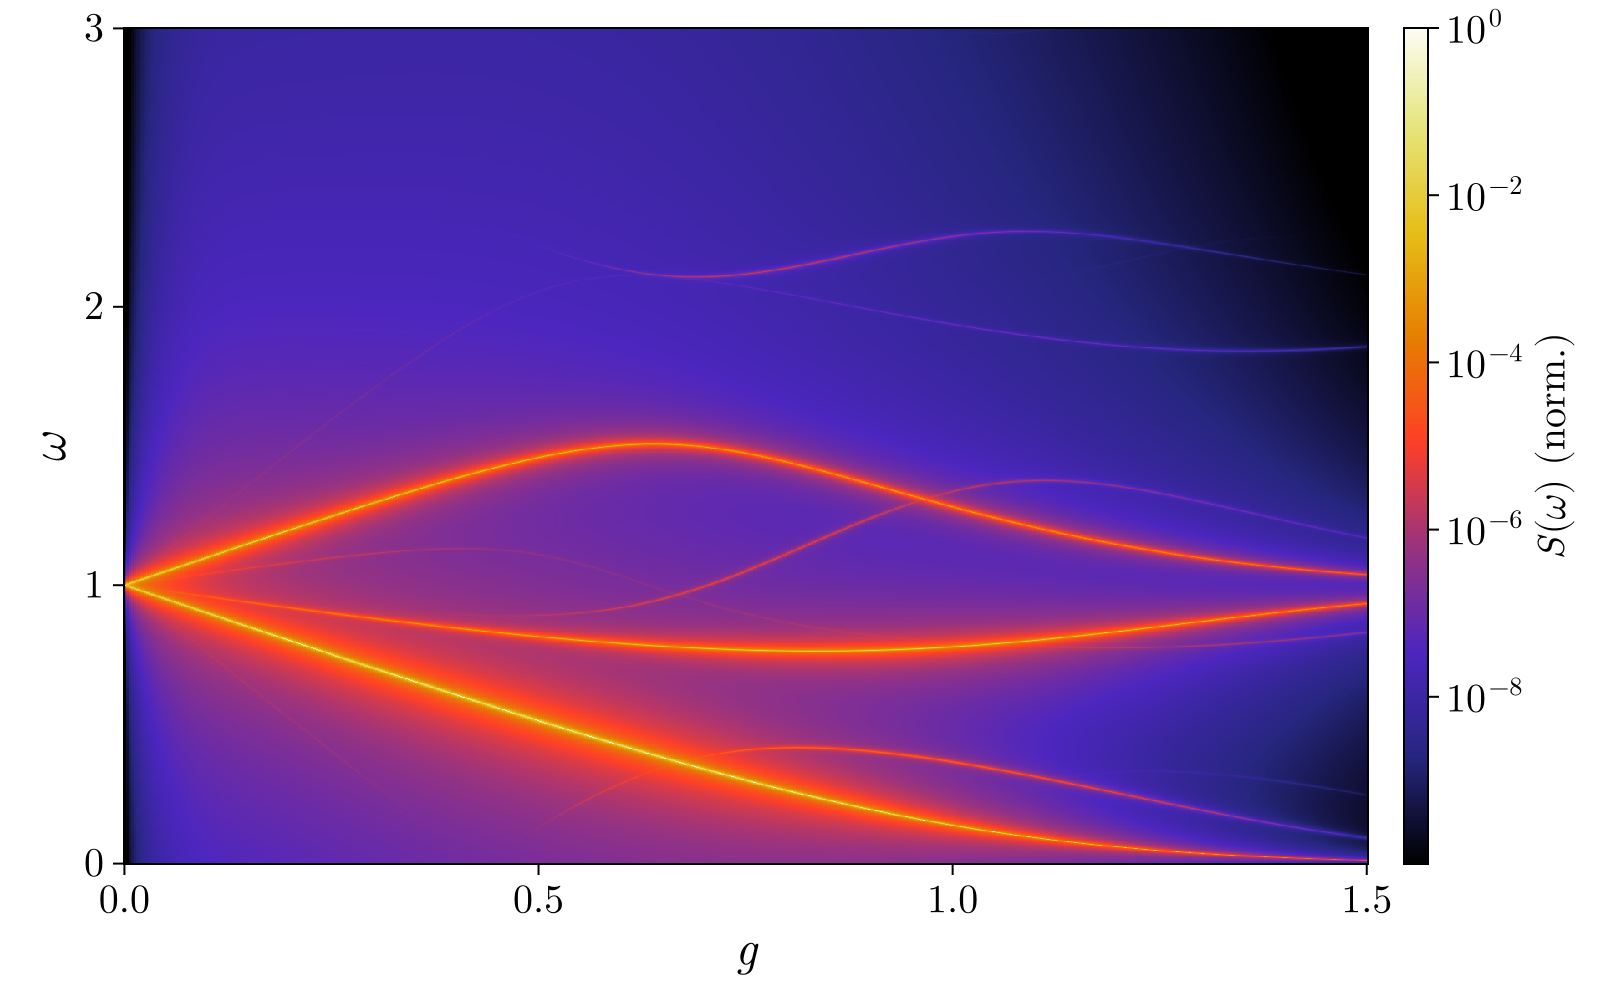

In [109]:
vars_em = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
γ_em, T_em, NT_em = 0.001, 0.15, 10

g_list_em = range(1e-3, 1.5, 500) |> collect
ω_em = range(1e-5, 3.0, 1000) |> collect

S_map = zeros(length(ω_em), length(g_list_em))

Prog = Progress(length(g_list_em))
Threads.@threads for j in eachindex(g_list_em)
    g_em = g_list_em[j]
    E_em, U_em, L_em = gen_liouvillian_qrm(g_em, vars_em, γ_em; T = [0.0, T_em], N_trunc = NT_em, σ_filter = 0.1, tol = 1e-20)

    Ed = U_em.data' * qrm_emission_field(g_em, vars_em).data * U_em.data
    Eplus = Qobj(triu(Ed, 1), dims=(NT_em,))

    S_em = real.(spectrum(L_em, ω_em, nothing, Eplus', Eplus, solver=ExponentialSeries(tol=1e-20, calc_steadystate=true)))
    # S_em ./= maximum(S_em)
    S_map[:, j] .= S_em

    next!(Prog)
end

S_map ./= maximum(S_map)
S_map_log = map(x -> x > 0 ? x : NaN, S_map)  

fig_em_map = Figure()
ax = Axis(fig_em_map[1, 1]; xlabel = L"g", ylabel = L"\omega")
hm = heatmap!(ax, g_list_em, ω_em, S_map_log'; colormap = :CMRmap, colorscale = log10, colorrange = (1e-10, 1.0))
Colorbar(fig_em_map[1, 2], hm; label = L"S(\omega)\ \mathrm{(norm.)}")

# save("Julia/NHQRM/emission_spectrum_map.png", fig_em_map; px_per_unit = 3)
fig_em_map

## LEP

In [139]:
function max_eigmat_overlap(g, γa, γb; σ_filter = 0.1, tol = 1e-20)
    _, _, L = gen_liouvillian_qrm(g, vars_map, [γa, γb], N_trunc = NT_map, σ_filter = σ_filter, tol = tol)
    F = eigen(Matrix(L.data))
    V = F.vectors
    for j in axes(V, 2) 
        V[:, j] ./= norm(V[:, j])
    end
    G = abs.(V' * V)

    s = argmin(abs.(F.values))
    n = length(F.values)
    G[s, :] .= 0
    G[:, s] .= 0
    for i in 1:n
        G[i, i] = 0
    end   # eclude steady state and diagonal
    
    return maximum(G)
end

function max_eigmat_ep(g, γa, γb; σ_filter = 0.1, tol = 1e-20, tol_val=1e-4)
    _, _, L = gen_liouvillian_qrm(g, vars_map, [γa, γb], N_trunc = NT_map, σ_filter = σ_filter, tol = tol)
    F = eigen(Matrix(L.data))
    vecs = F.vectors
    for j in axes(vecs, 2) 
        vecs[:, j] ./= norm(vecs[:, j])
    end
    G = abs.(vecs' * vecs)
    
    s = argmin(abs.(F.values))
    n = length(F.values)
    G[s, :] .= 0
    G[:, s] .= 0
    for i in 1:n
        G[i, i] = 0
    end   # eclude steady state and diagonal

    ep_check = true ? abs(F.values[argmax(G)[1]]-F.values[argmax(G)[2]])<tol_val : false

    return maximum(G), ep_check, F.values[argmax(G)[1]], F.values[argmax(G)[2]]
end

max_eigmat_ep (generic function with 2 methods)

### Scanning $g$ and $\gamma_a$

Progress: 100%|█████████████████████████████████████████| Time: 0:02:17


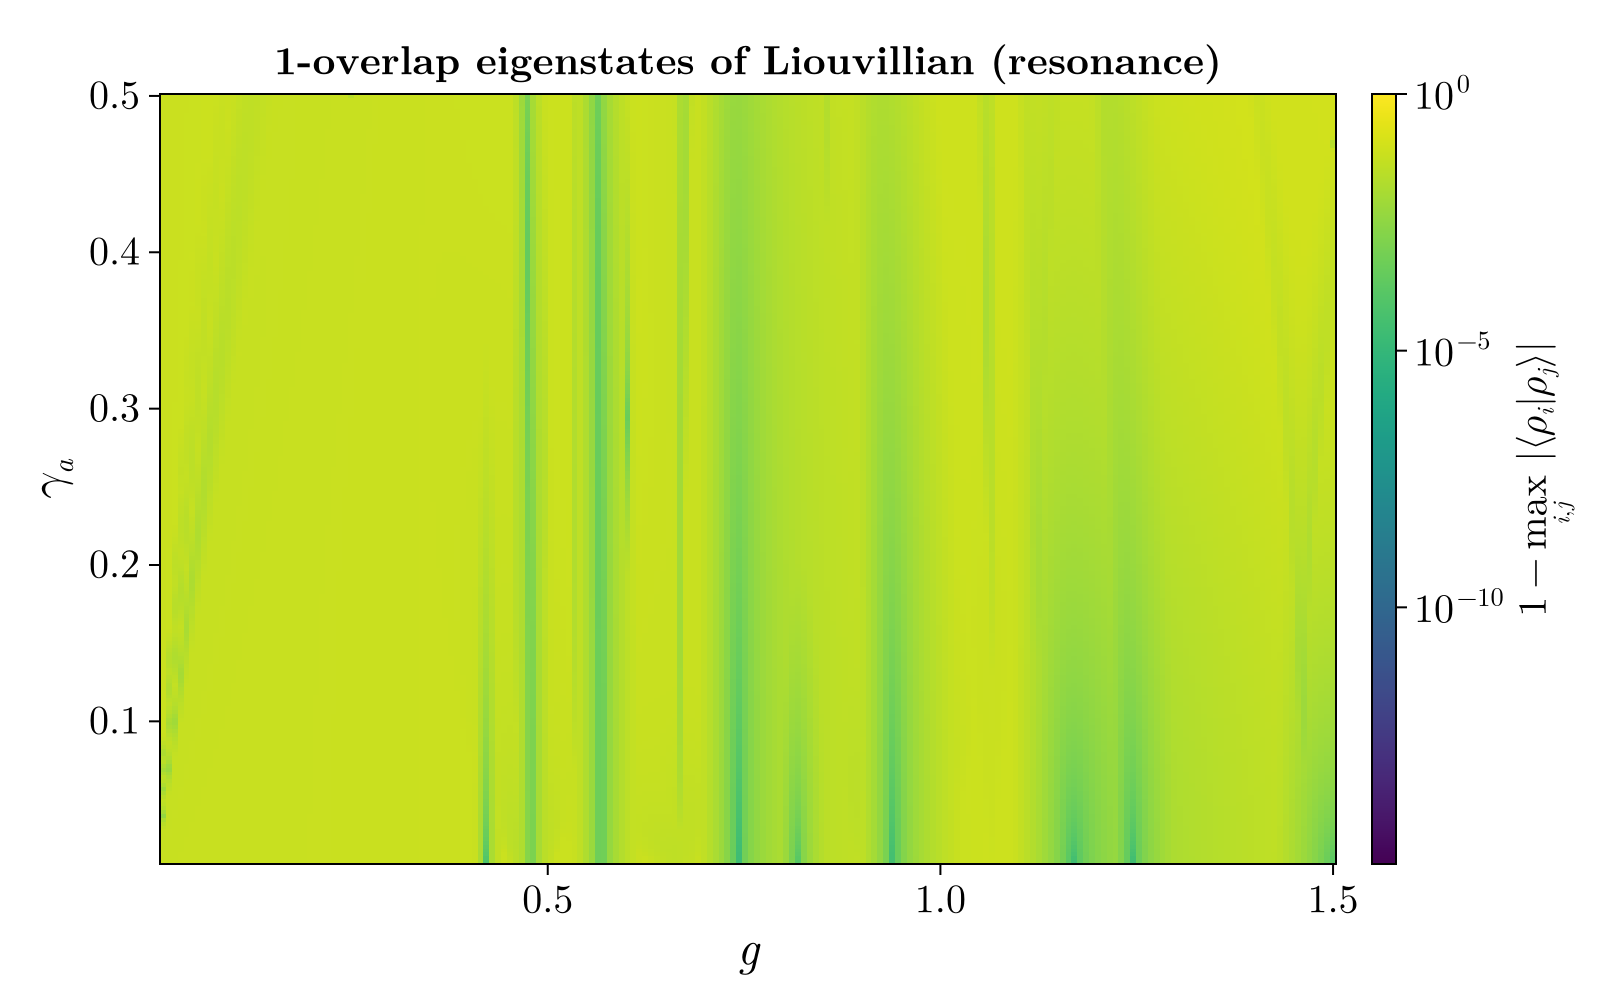

In [ ]:
vars_map = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
g_map  = range(0.01, 1.5, 200) |> collect
γa_map  = range(0.001, 0.1, 200) |> collect
NT_map = 10

OVL_map_non_sec = fill(0.0, length(g_map), length(γa_map))

Prog = Progress(length(g_map))
Threads.@threads for i in eachindex(g_map)
    for j in eachindex(γa_map)
        OVL_map_non_sec[i, j] = 1.0 - max_eigmat_overlap(g_map[i], γa_map[j], 0.0; σ_filter = 10, tol = 1e-20)
    end
    next!(Prog)
end

fig_ovl = Figure()
ax = Axis(fig_ovl[1, 1]; xlabel = L"g", ylabel = L"\gamma_a", title = "1-overlap eigenstates of Liouvillian (resonance)")
hm = heatmap!(ax, g_map, γa_map, OVL_map_non_sec; colormap = :viridis, colorscale = log10, colorrange = (1e-15, 1.0))
Colorbar(fig_ovl[1, 2], hm; label = L"1-\max_{i,j}\,|\langle\rho_i|\rho_j\rangle|")

# save("usc_overlap_map.png", fig_ovl; px_per_unit = 3)
fig_ovl

Progress: 100%|█████████████████████████████████████████| Time: 0:02:07


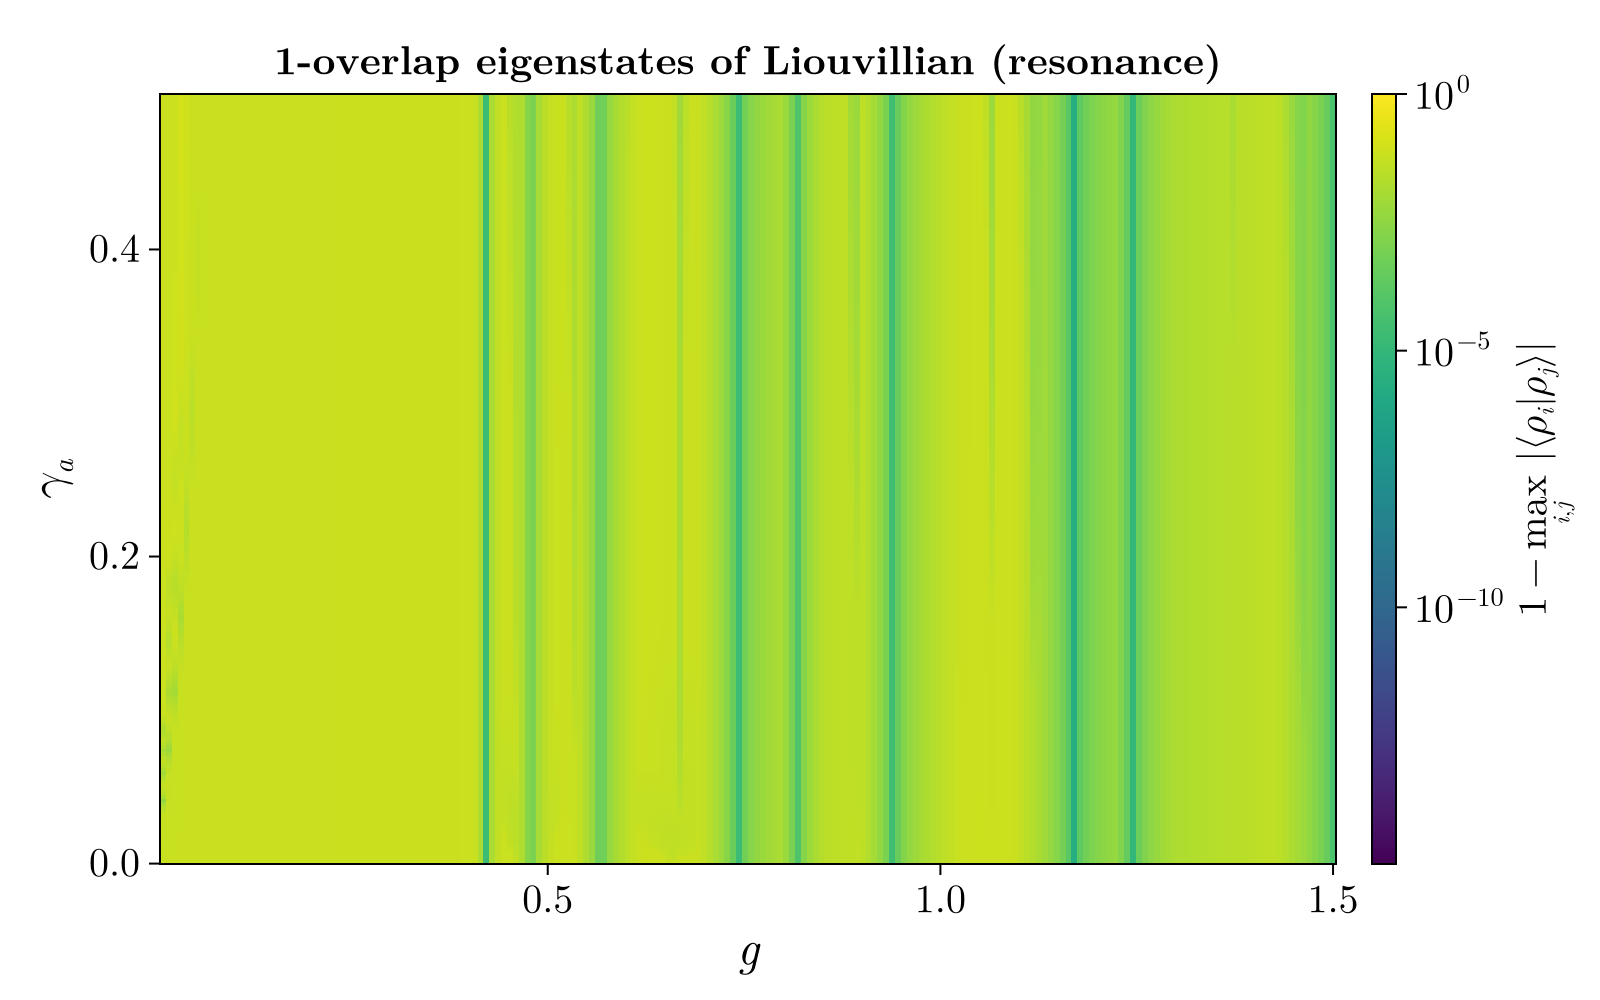

In [ ]:
vars_map = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
g_map  = range(0.01, 1.5, 200) |> collect
γa_map  = range(0.001, 0.1, 200) |> collect
NT_map = 10

OVL_map_sec = fill(0.0, length(g_map), length(γa_map))

Prog = Progress(length(g_map))
Threads.@threads for i in eachindex(g_map)
    for j in eachindex(γa_map)
        OVL_map_sec[i, j] = 1.0 - max_eigmat_overlap(g_map[i], γa_map[j], 0.0; σ_filter = 0.1, tol = 1e-20)
    end
    next!(Prog)
end

fig_ovl = Figure()
ax = Axis(fig_ovl[1, 1]; xlabel = L"g", ylabel = L"\gamma_a", title = "1-overlap eigenstates of Liouvillian (resonance)")
hm = heatmap!(ax, g_map, γa_map, OVL_map_sec; colormap = :viridis, colorscale = log10, colorrange = (1e-15, 1.0))
Colorbar(fig_ovl[1, 2], hm; label = L"1-\max_{i,j}\,|\langle\rho_i|\rho_j\rangle|")

# save("usc_overlap_map.png", fig_ovl; px_per_unit = 3)
fig_ovl

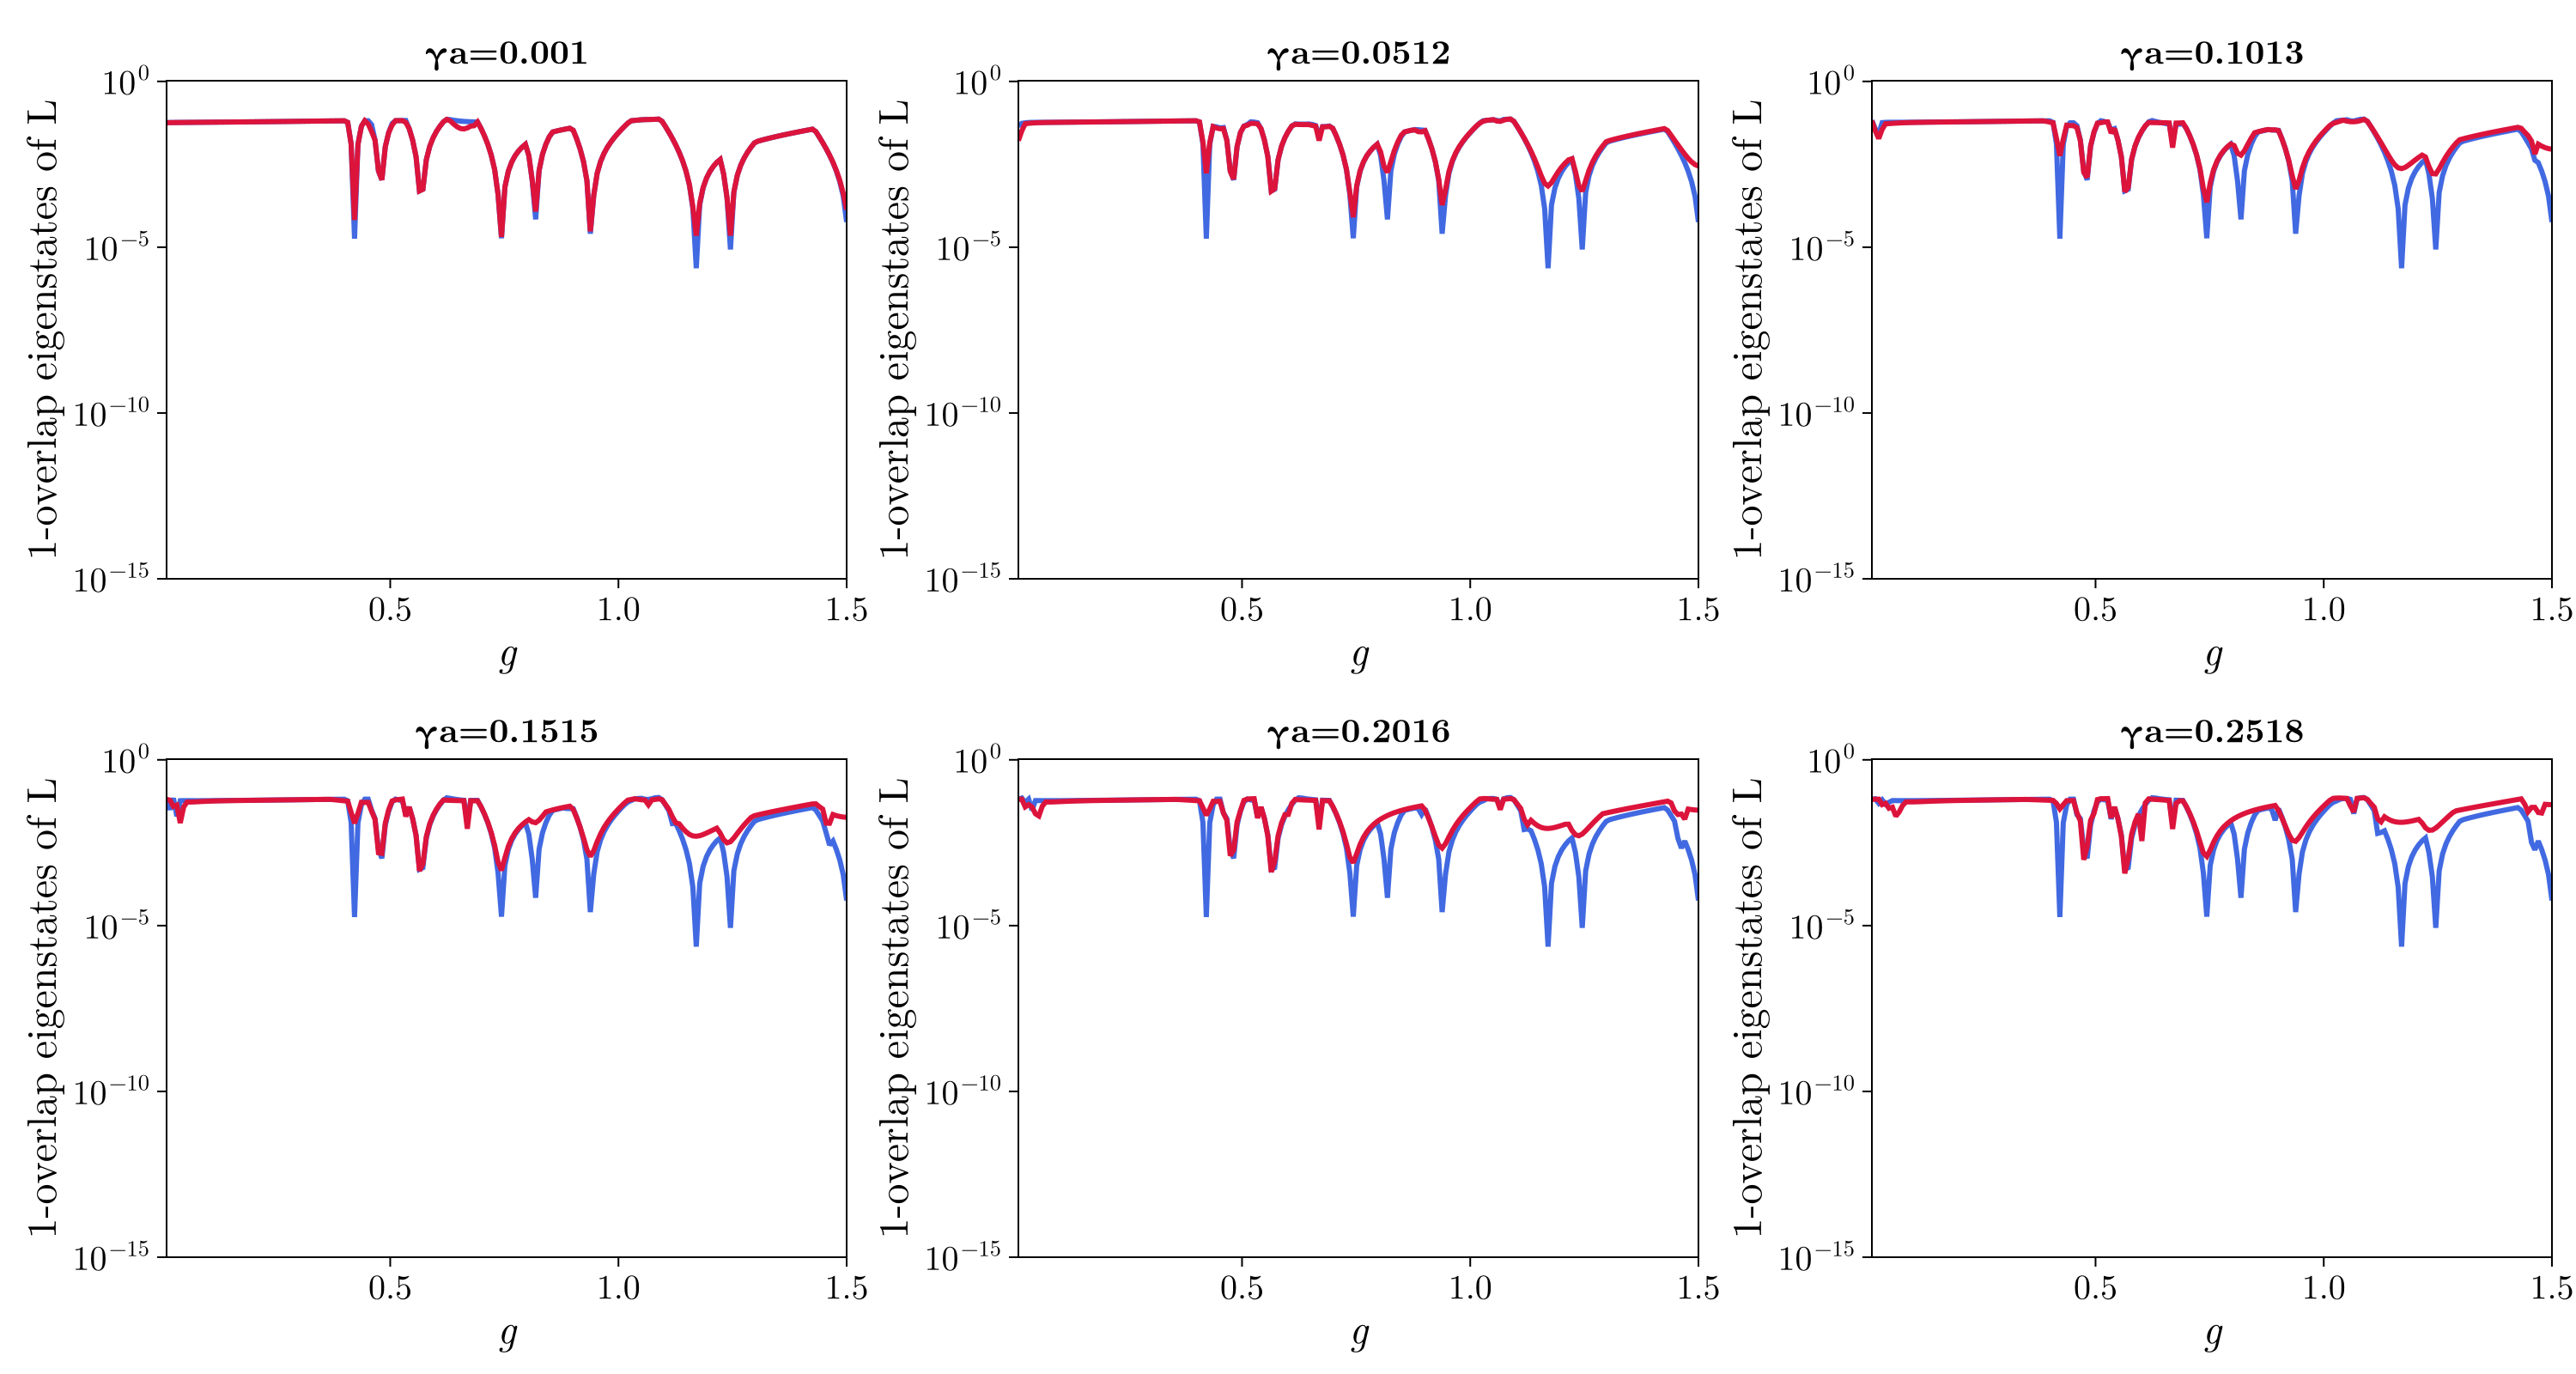

In [132]:
step_ind = 20
inds = 1:step_ind:(5*step_ind+1)

fig_comp = Figure(size = (1500, 800))
for (subplot, ind) in enumerate(inds)
    row = cld(subplot, 3)
    col = mod1(subplot, 3)
    ax = Axis(fig_comp[row, col]; xlabel = L"g", ylabel = "1-overlap eigenstates of L", title = "γa=$(round(γa_map[ind], digits=4))", limits = ((g_map[1], g_map[end]), (1e-15, 1.05)), yscale = log10)
    lines!(ax, g_map, OVL_map_sec[:, ind]; color = :royalblue)
    lines!(ax, g_map, OVL_map_non_sec[:, ind]; color = :crimson)
end

# save("usc_overlap_map.png", fig_comp; px_per_unit = 3)
fig_comp

### Scanning $\gamma_a$ and $\gamma_b$ in USC

Progress: 100%|█████████████████████████████████████████| Time: 0:13:10


min overlap = 0.9338247960382745 at (γa, γb) = (0.199, 0.332)
max overlap (1-overlap) = 1.4954704141700859e-13 at (γa, γb) = (0.011, 0.246)


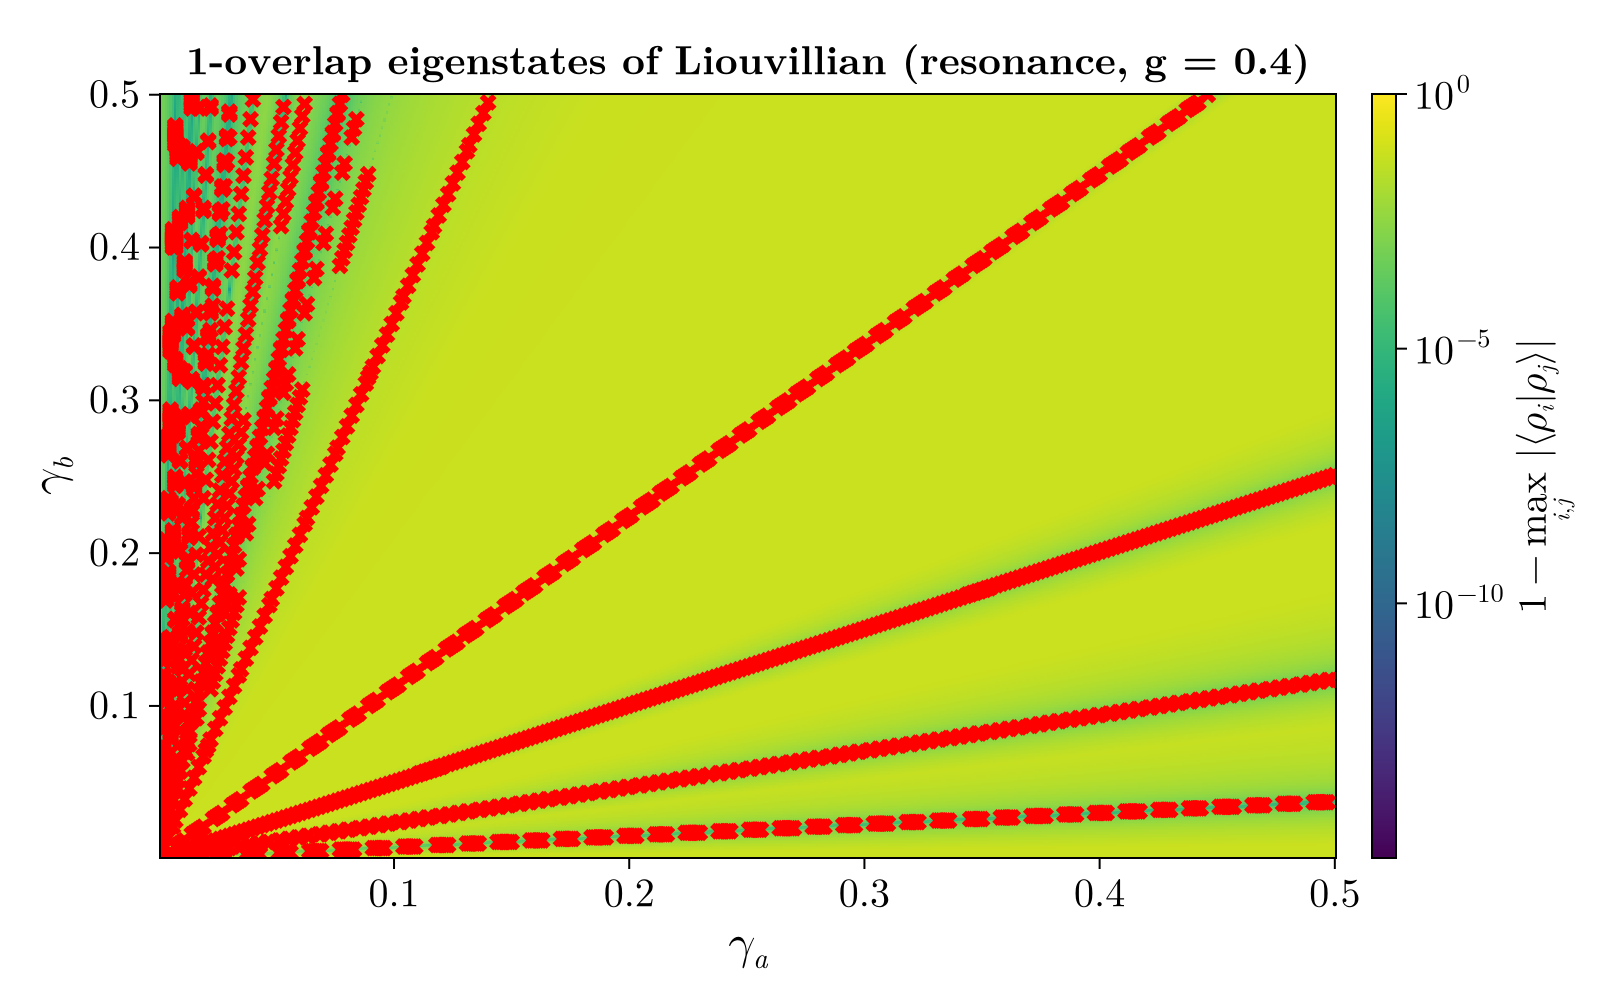

In [144]:
vars_map = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
γa_map  = range(0.001, 0.5, 500) |> collect
γb_map  = range(0.001, 0.5, 500) |> collect
g_map = 0.4
NT_map = 10

OVL_map = fill(0.0, length(γa_map), length(γb_map))
OVL_map_check = fill(false, length(γa_map), length(γb_map))
eigvals_ep = Tuple{ComplexF64, ComplexF64, Float64, Float64}[]

Prog = Progress(length(γa_map))
Threads.@threads for i in eachindex(γa_map)
    for j in eachindex(γb_map)
        vv = max_eigmat_ep(g_map, γa_map[i], γb_map[j], tol_val=1e-4, σ_filter = 0.1, tol = 1e-20)
        OVL_map[i, j] = 1.0 - vv[1]
        OVL_map_check[i, j] = vv[2]
        if vv[2]
            push!(eigvals_ep, (vv[3], vv[4], γa_map[i], γb_map[j]))
        end
    end
    next!(Prog)
end
println("min overlap = ", 1.0-maximum(OVL_map), " at (γa, γb) = (", round(γa_map[argmax(OVL_map)[1]], digits = 4), ", ", round(γb_map[argmax(OVL_map)[2]], digits = 4), ")")
println("max overlap (1-overlap) = ", minimum(OVL_map), " at (γa, γb) = (", round(γa_map[argmin(OVL_map)[1]], digits = 4), ", ", round(γb_map[argmin(OVL_map)[2]], digits = 4), ")")

fig_ovl = Figure()
ax = Axis(fig_ovl[1, 1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b", title = "1-overlap eigenstates of Liouvillian (resonance, g = $g_map)")
hm = heatmap!(ax, γa_map, γb_map, OVL_map; colormap = :viridis, colorscale = log10, colorrange = (1e-15, 1.0))
Colorbar(fig_ovl[1, 2], hm; label = L"1-\max_{i,j}\,|\langle\rho_i|\rho_j\rangle|")

# save("Julia/NHQRM/USC_overlap_map_gamma_g04.pdf", fig_ovl; px_per_unit = 3)

for ind in findall(OVL_map_check)
    scatter!(ax, [γa_map[ind[1]]], [γb_map[ind[2]]]; color = :red, marker = :xcross, markersize = 12)
end

# save("Julia/NHQRM/USC_overlap_map_gamma_g04_withEP.pdf", fig_ovl; px_per_unit = 3)
fig_ovl

Progress: 100%|█████████████████████████████████████████| Time: 0:14:26


min overlap = 0.933030178108252 at (γa, γb) = (0.071, 0.173)
max overlap (1-overlap) = 1.3402658982641924e-8 at (γa, γb) = (0.014, 0.221)


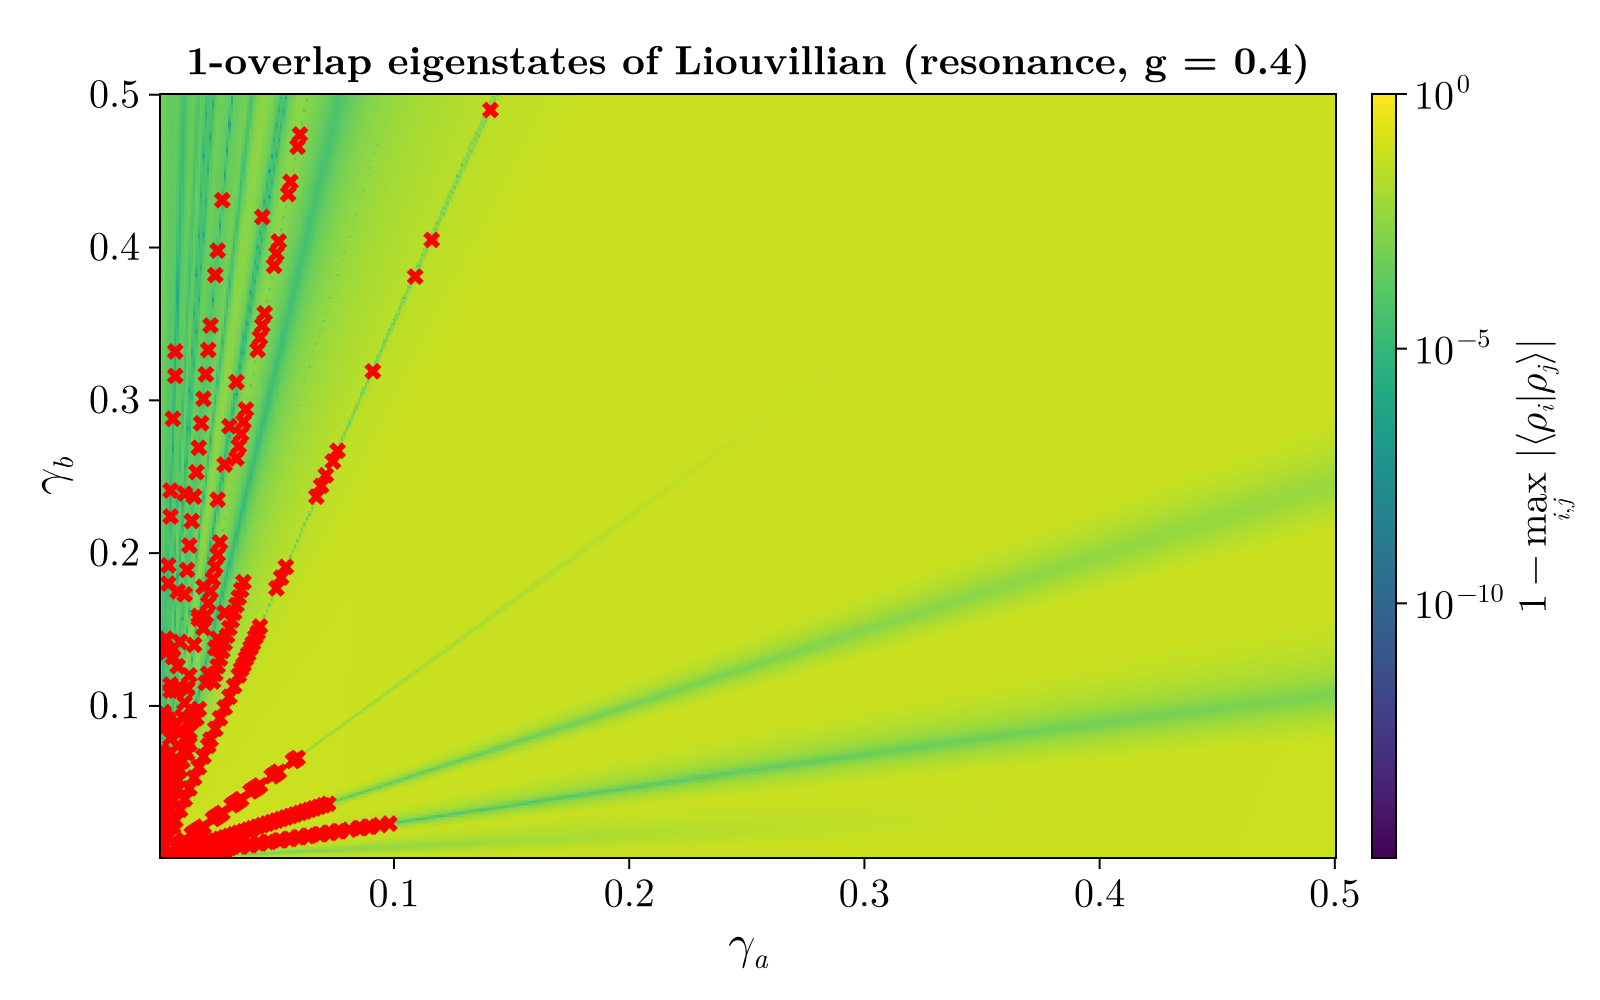

In [145]:
vars_map = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
γa_map  = range(0.001, 0.5, 500) |> collect
γb_map  = range(0.001, 0.5, 500) |> collect
g_map = 0.4
NT_map = 10

OVL_map = fill(0.0, length(γa_map), length(γb_map))
OVL_map_check = fill(false, length(γa_map), length(γb_map))
eigvals_ep = Tuple{ComplexF64, ComplexF64, Float64, Float64}[]

Prog = Progress(length(γa_map))
Threads.@threads for i in eachindex(γa_map)
    for j in eachindex(γb_map)
        vv = max_eigmat_ep(g_map, γa_map[i], γb_map[j], tol_val=1e-4, σ_filter = 10, tol = 1e-20)
        OVL_map[i, j] = 1.0 - vv[1]
        OVL_map_check[i, j] = vv[2]
        if vv[2]
            push!(eigvals_ep, (vv[3], vv[4], γa_map[i], γb_map[j]))
        end
    end
    next!(Prog)
end
println("min overlap = ", 1.0-maximum(OVL_map), " at (γa, γb) = (", round(γa_map[argmax(OVL_map)[1]], digits = 4), ", ", round(γb_map[argmax(OVL_map)[2]], digits = 4), ")")
println("max overlap (1-overlap) = ", minimum(OVL_map), " at (γa, γb) = (", round(γa_map[argmin(OVL_map)[1]], digits = 4), ", ", round(γb_map[argmin(OVL_map)[2]], digits = 4), ")")

fig_ovl = Figure()
ax = Axis(fig_ovl[1, 1]; xlabel = L"\gamma_a", ylabel = L"\gamma_b", title = "1-overlap eigenstates of Liouvillian (resonance, g = $g_map)")
hm = heatmap!(ax, γa_map, γb_map, OVL_map; colormap = :viridis, colorscale = log10, colorrange = (1e-15, 1.0))
Colorbar(fig_ovl[1, 2], hm; label = L"1-\max_{i,j}\,|\langle\rho_i|\rho_j\rangle|")

# save("Julia/NHQRM/USC_overlap_map_gamma_g04.pdf", fig_ovl; px_per_unit = 3)

for ind in findall(OVL_map_check)
    scatter!(ax, [γa_map[ind[1]]], [γb_map[ind[2]]]; color = :red, marker = :xcross, markersize = 12)
end

# save("Julia/NHQRM/USC_overlap_map_gamma_g04_withEP.pdf", fig_ovl; px_per_unit = 3)
fig_ovl

### Liouvillian eigenspectrum

In [189]:
eigvals_ep[161]

(-0.08085950020185659 + 3.0868732732802653e-15im, -0.08092927993726132 - 9.81390597779164e-16im, 0.021, 0.121)

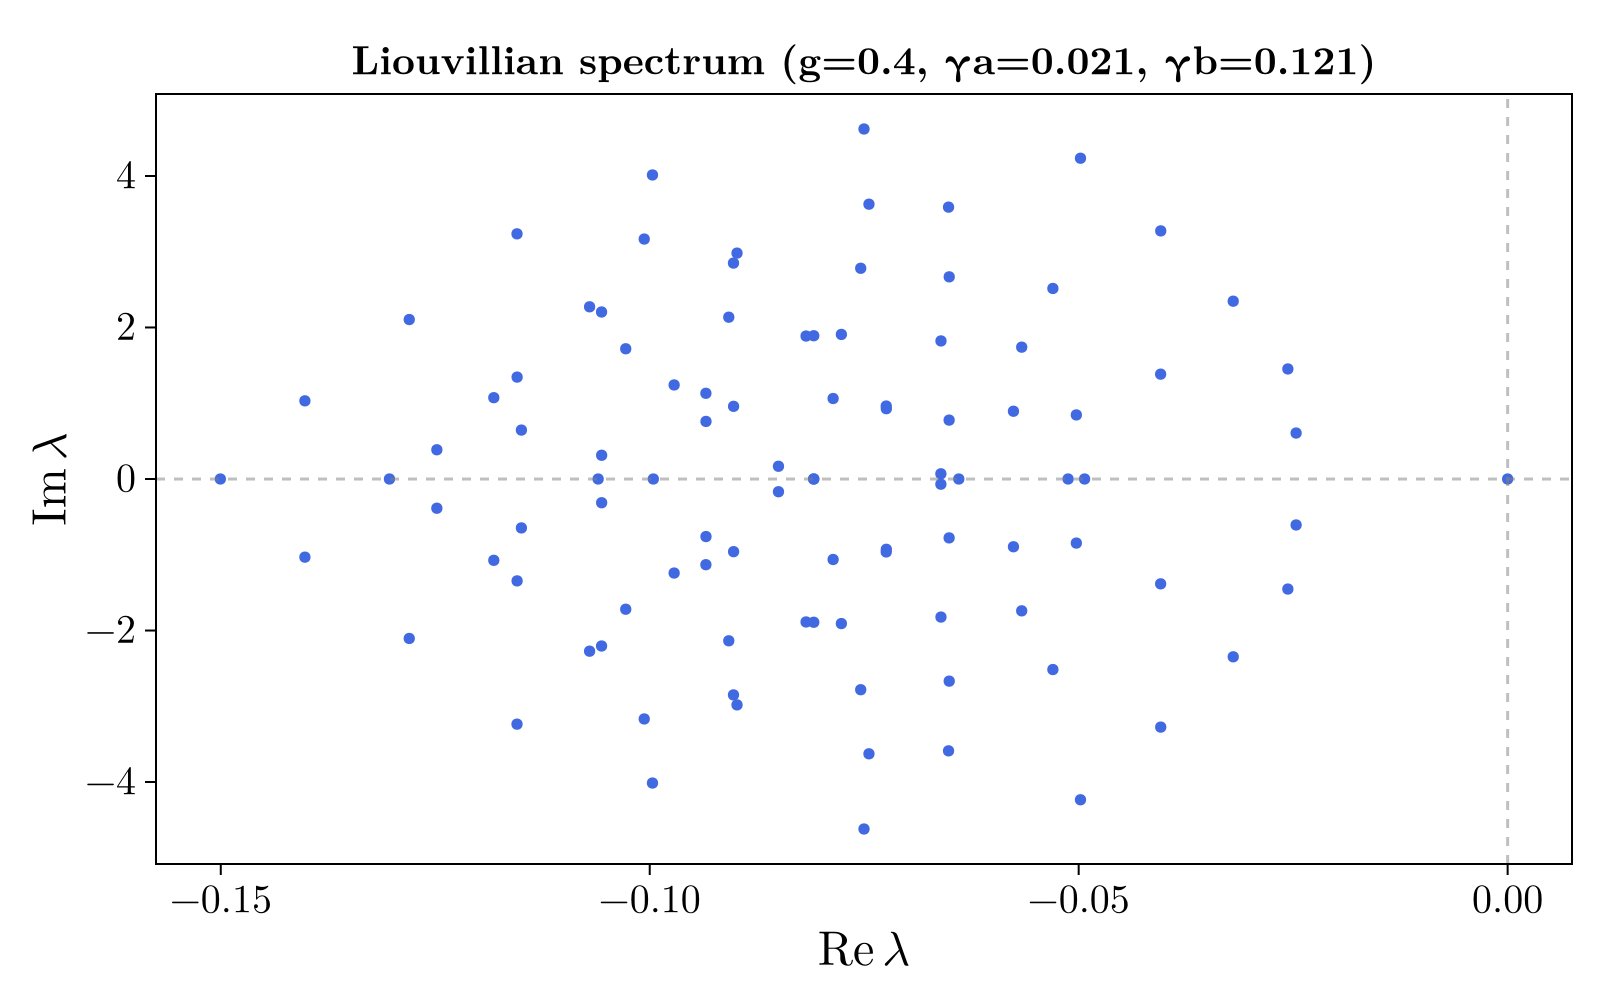

In [167]:
vars_sp = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
g_sp, NT_sp = 0.4, 10
_, _, L_sp = gen_liouvillian_qrm(g_sp, vars_sp, [eigvals_ep[161][3], eigvals_ep[161][4]], N_trunc = NT_sp, σ_filter = 0.1, tol = 1e-20)
λ_sp = eigvals(Matrix(L_sp.data))

fig_sp = Figure()
ax = Axis(fig_sp[1, 1]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda", title = "Liouvillian spectrum (g=$g_sp, γa=$(eigvals_ep[161][3]), γb=$(eigvals_ep[161][4]))")
scatter!(ax, real.(λ_sp), imag.(λ_sp); color = :royalblue, markersize = 8)

vlines!(ax, 0; color = (:grey, 0.5), linestyle = :dash)
hlines!(ax, 0; color = (:grey, 0.5), linestyle = :dash)

# save("liouvillian_spectrum.png", fig_sp; px_per_unit = 3)
fig_sp

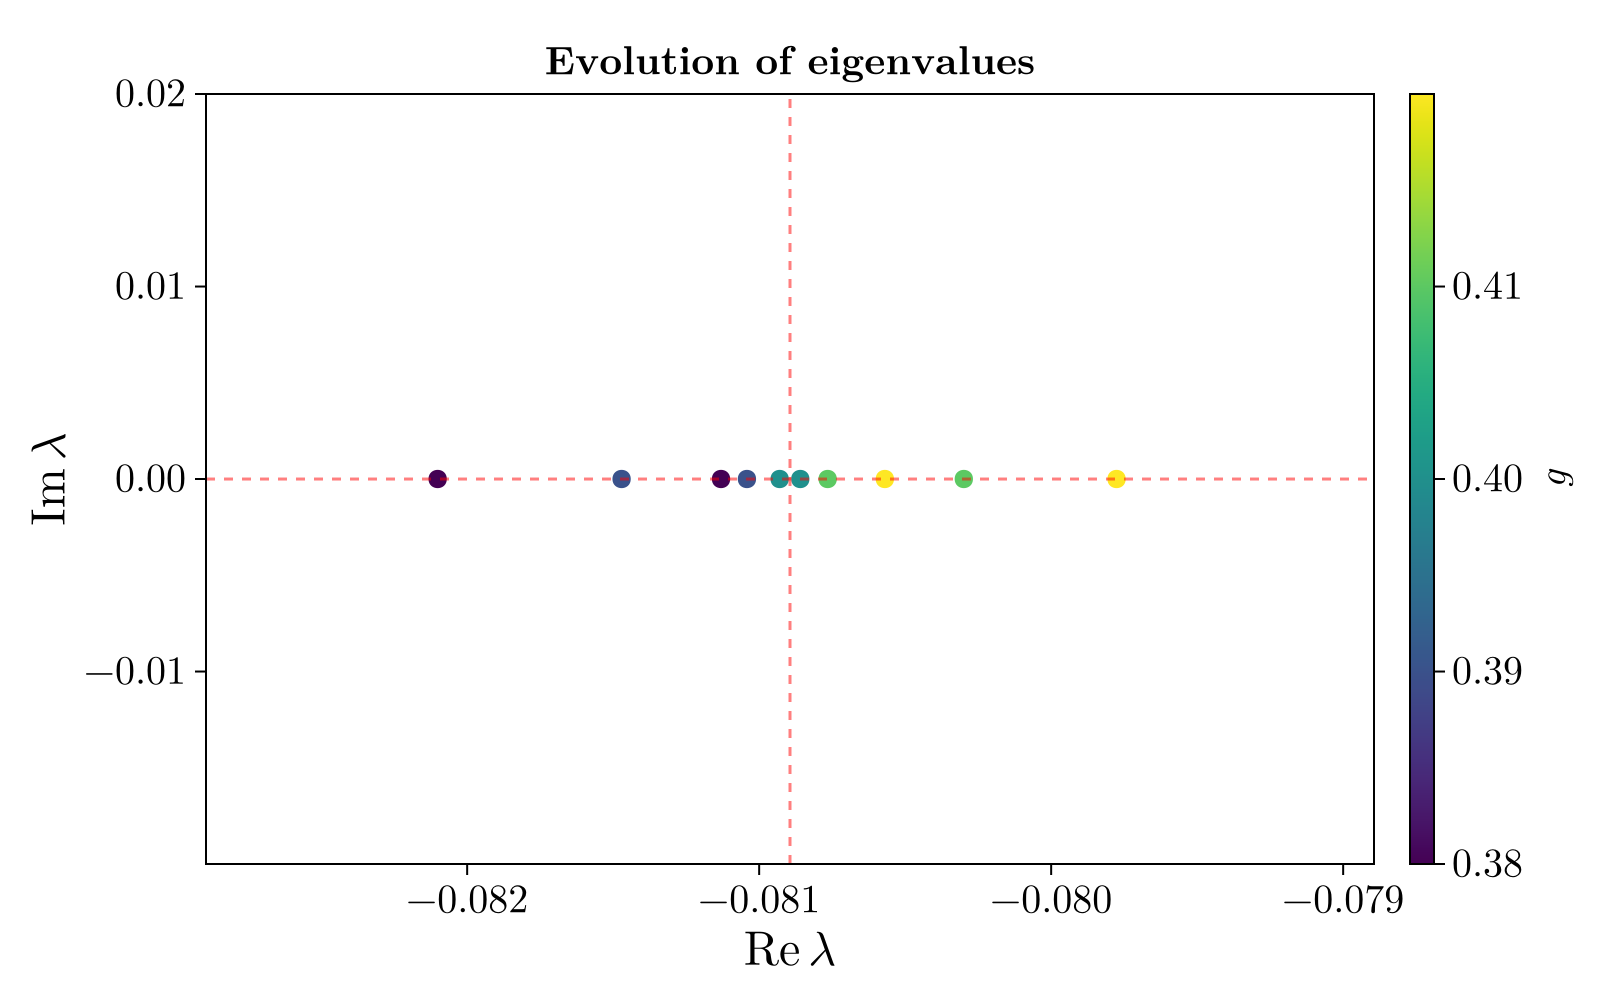

In [187]:
ind = 161
g_ev = range(0.38, 0.42, 5) |> collect
# g_ev = 0.3989

fig_ev = Figure()
ax = Axis(fig_ev[1, 1]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda", title = "Evolution of eigenvalues", limits = ((real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.002, real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.002),(imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.02, imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.02)))
for g in g_ev
    _, _, L = gen_liouvillian_qrm(g, vars_map, [eigvals_ep[ind][3], eigvals_ep[ind][4]], N_trunc = 10, tol = 1e-20)
    λ = eigvals(Matrix(L.data))
    sel = filter(z -> abs(real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2) + 0.01 > abs(real(z)) > abs(real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2) - 0.01 && imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.02 > abs(imag(z)) > imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.02, λ)
    scatter!(ax, real.(sel), imag.(sel); color = fill(g, length(sel)), colormap = :viridis, colorrange = (g_ev[1], g_ev[end]), markersize = 13)
end
Colorbar(fig_ev[1, 2]; limits = (g_ev[1], g_ev[end]), colormap = :viridis, label = L"g")

vlines!(ax, real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2; color = (:red, 0.5), linestyle = :dash)
hlines!(ax, imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2; color = (:red, 0.5), linestyle = :dash)

# save("eigenvalue_evolution.png", fig_ev; px_per_unit = 3)
fig_ev

In [203]:
eigvals_ep[73]

(-0.015284412443409584 - 6.149103036916965e-14im, -0.015375510834346236 + 5.145210181473623e-14im, 0.002, 0.057)

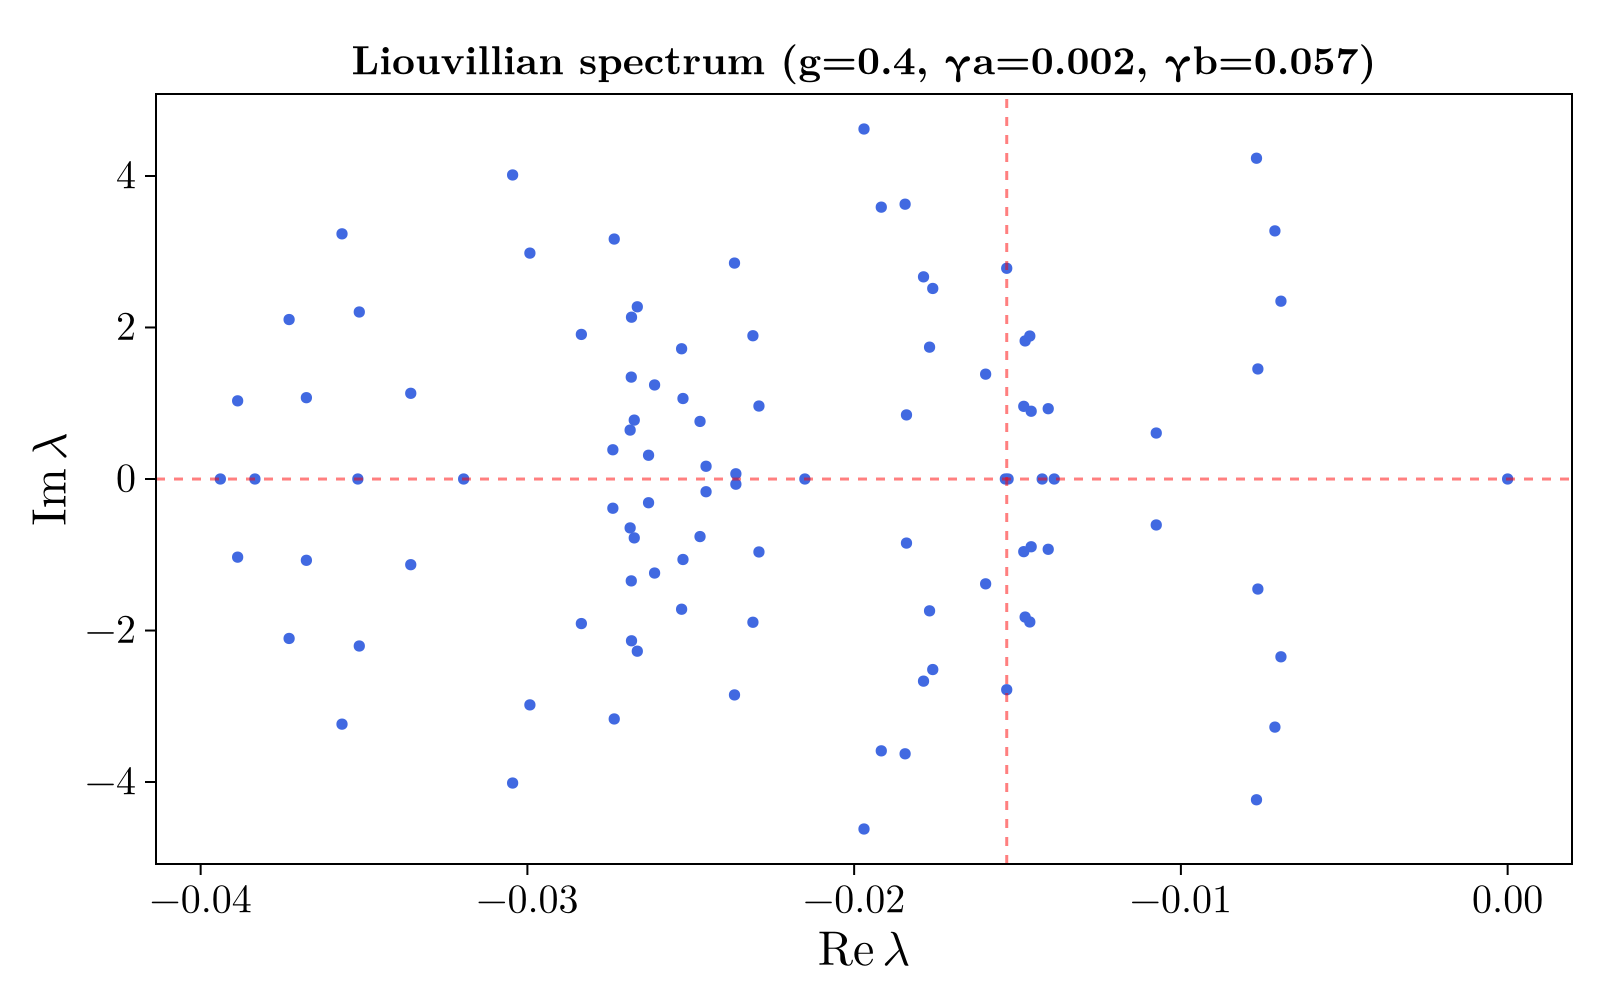

In [207]:
vars_sp = (ωa = 1.0, ωb = 1.0, Nc = 120, N = 1)
g_sp, NT_sp = 0.4, 10
_, _, L_sp = gen_liouvillian_qrm(g_sp, vars_sp, [eigvals_ep[73][3], eigvals_ep[73][4]], N_trunc = NT_sp, σ_filter = 0.1, tol = 1e-20)
λ_sp = eigvals(Matrix(L_sp.data))

fig_sp = Figure()
ax = Axis(fig_sp[1, 1]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda", title = "Liouvillian spectrum (g=$g_sp, γa=$(eigvals_ep[73][3]), γb=$(eigvals_ep[73][4]))")
scatter!(ax, real.(λ_sp), imag.(λ_sp); color = :royalblue, markersize = 8)

vlines!(ax, real(eigvals_ep[73][1]+eigvals_ep[73][2])/2; color = (:red, 0.5), linestyle = :dash)
hlines!(ax, imag(eigvals_ep[73][1]+eigvals_ep[73][2])/2; color = (:red, 0.5), linestyle = :dash)

# save("liouvillian_spectrum.png", fig_sp; px_per_unit = 3)
fig_sp

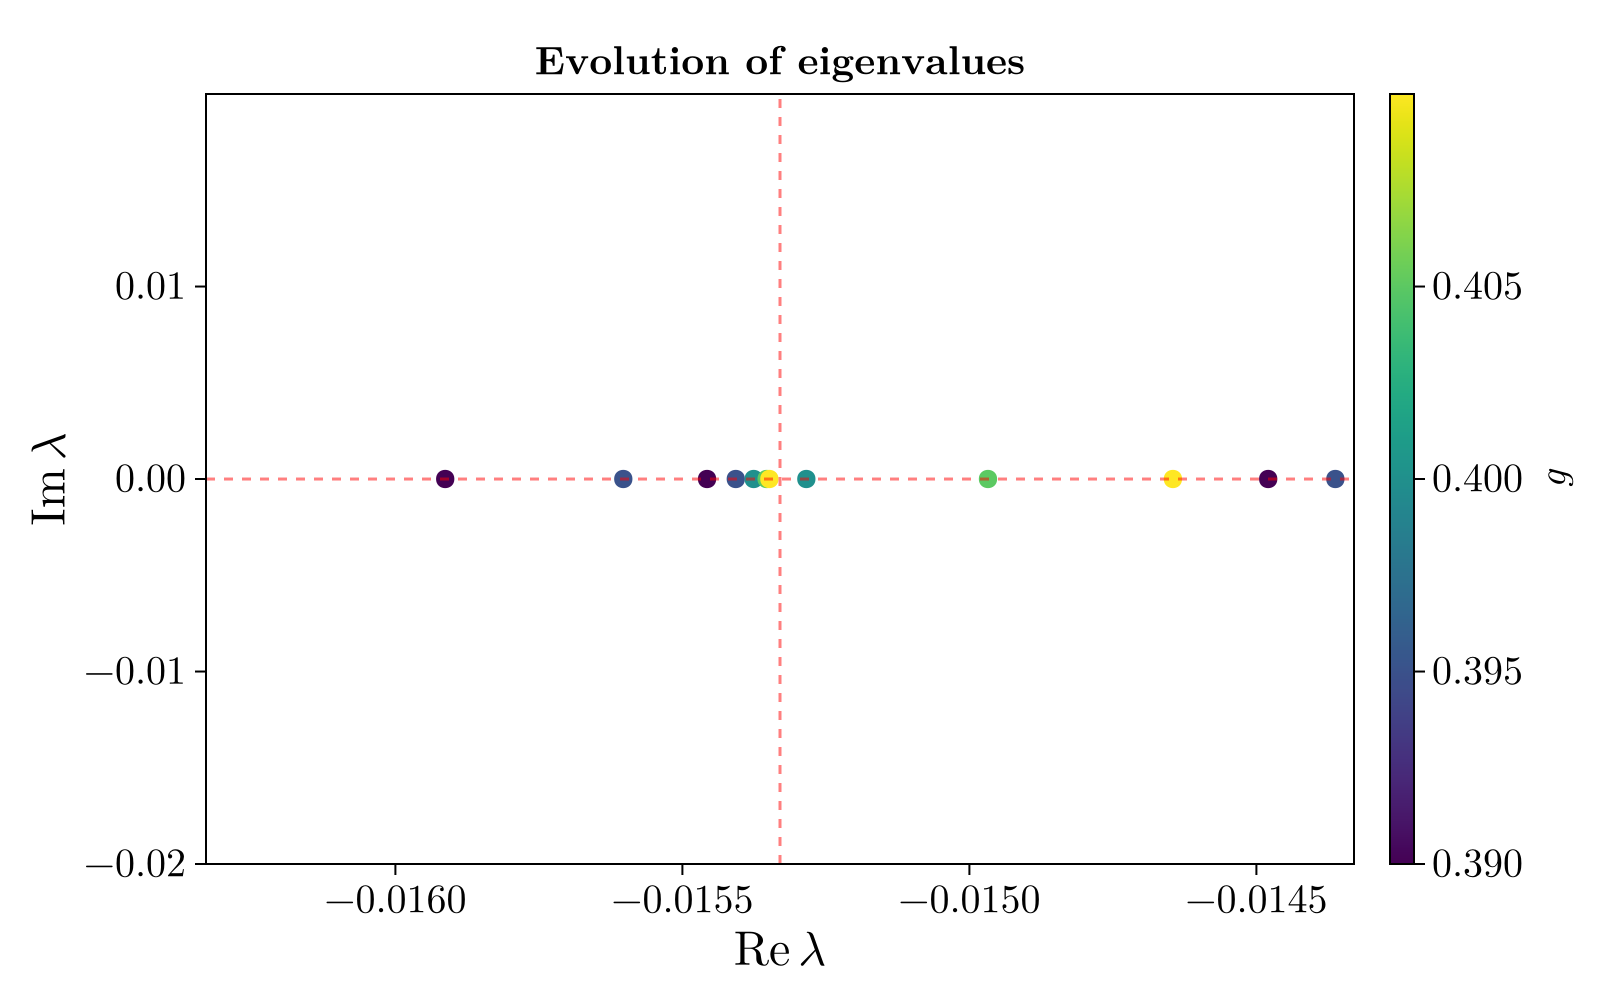

In [221]:
ind = 73
g_ev = range(0.39, 0.41, 5) |> collect
# g_ev = 0.4

fig_ev = Figure()
ax = Axis(fig_ev[1, 1]; xlabel = L"\mathrm{Re}\,\lambda", ylabel = L"\mathrm{Im}\,\lambda", title = "Evolution of eigenvalues", limits = ((real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.001, real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.001),(imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.02, imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.02)))
for g in g_ev
    _, _, L = gen_liouvillian_qrm(g, vars_map, [eigvals_ep[ind][3], eigvals_ep[ind][4]], N_trunc = 10, tol = 1e-20)
    λ = eigvals(Matrix(L.data))
    sel = filter(z -> abs(real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2) + 0.002 > abs(real(z)) > abs(real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2) - 0.002 && imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 + 0.02 > abs(imag(z)) > imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2 - 0.02, λ)
    scatter!(ax, real.(sel), imag.(sel); color = fill(g, length(sel)), colormap = :viridis, colorrange = (g_ev[1], g_ev[end]), markersize = 13)
end
Colorbar(fig_ev[1, 2]; limits = (g_ev[1], g_ev[end]), colormap = :viridis, label = L"g")

vlines!(ax, real(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2; color = (:red, 0.5), linestyle = :dash)
hlines!(ax, imag(eigvals_ep[ind][1]+eigvals_ep[ind][2])/2; color = (:red, 0.5), linestyle = :dash)

# save("eigenvalue_evolution.png", fig_ev; px_per_unit = 3)
fig_ev

In [235]:
function Lmat(g, ωb, γ; Nc, NT)
    v = (ωa = 1.0, ωb = ωb, Nc = Nc, N = 1)
    _, _, L = gen_liouvillian_qrm(g, v, γ; N_trunc = NT)
    return Matrix(L.data)
end

function is_ep(x0, y0, κ0; knob = :ωb, r = 0.01, nθ = 200, Nc = 20, NT = 6)
    Lf = knob === :ωb ? ((x, y) -> Lmat(x, y, κ0; Nc, NT)) : ((x, y) -> Lmat(x, 1.0, y; Nc, NT))
    c = eigvals(Lf(x0, y0)); n = length(c); dmin = Inf; λ0 = 0.0im
    for i in 1:n, j in i+1:n
        d = abs(c[i] - c[j]); d < dmin && (dmin = d; λ0 = (c[i] + c[j]) / 2)
    end
    v = eigvals(Lf(x0 + r, y0)); ord = sortperm(abs.(v .- λ0)); λ1, λ2 = v[ord[1]], v[ord[2]]
    λ1s, λ2s = λ1, λ2
    for k in 1:nθ
        θ = 2π * k / nθ; v = eigvals(Lf(x0 + r*cos(θ), y0 + r*sin(θ)))
        mid = (λ1 + λ2) / 2; ord = sortperm(abs.(v .- mid)); a1, a2 = v[ord[1]], v[ord[2]]
        if abs(a1-λ1)+abs(a2-λ2) <= abs(a1-λ2)+abs(a2-λ1); λ1, λ2 = a1, a2; else; λ1, λ2 = a2, a1; end
    end
    swapped = abs(λ1-λ2s)+abs(λ2-λ1s) < abs(λ1-λ1s)+abs(λ2-λ2s)
    return swapped, dmin
end

is_ep (generic function with 1 method)

Progress: 100%|█████████████████████████████████████████| Time: 0:31:15


Candidati:   g       γa      gap          loc
           0.817   0.001   1.89e-9      -0.00394 + 0.0im
           0.817   0.001   2.07e-9      -0.00433 + 0.0im
           0.817   0.001   2.26e-9      -0.00472 + 0.0im
           0.817   0.001   2.45e-9      -0.00511 + 0.0im
           0.817   0.001   2.63e-9      -0.00551 + 0.0im
           0.817   0.001   2.82e-9      -0.0059 + 0.0im
           0.817   0.002   3.01e-9      -0.00629 + 0.0im
           0.817   0.002   3.2e-9       -0.00668 + 0.0im


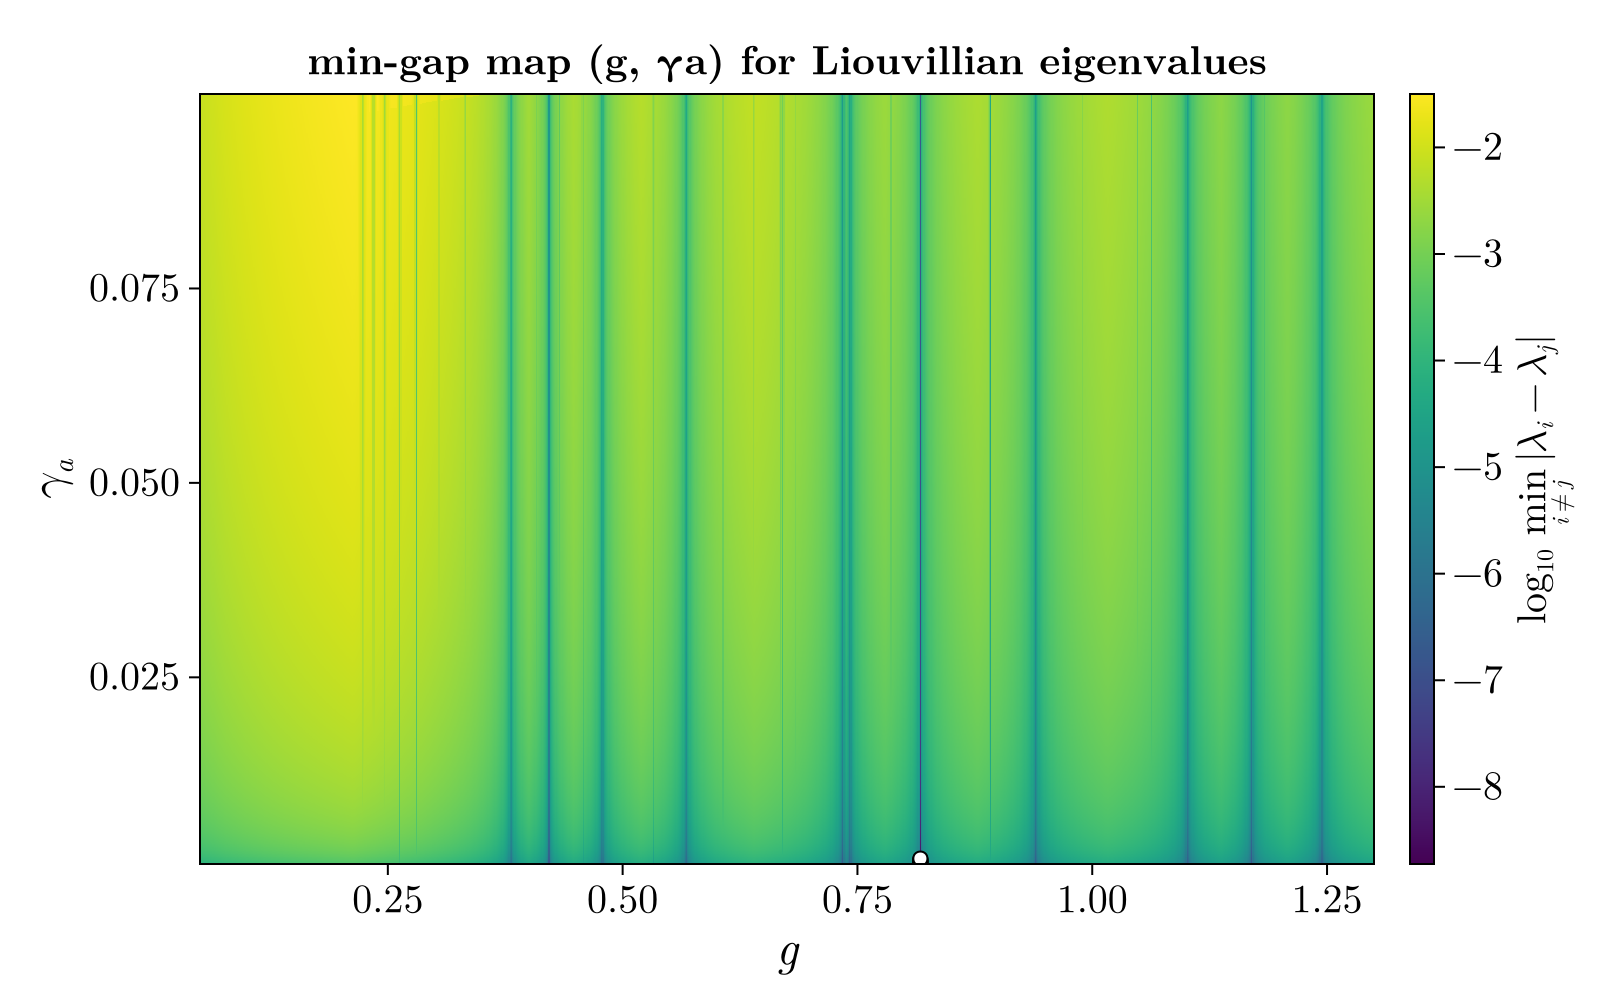

In [ ]:
vars_ep     = (ωa = 1.0, ωb = 1.0, Nc = 80, N = 1)
NT_ep, σ_ep = 12, 0.1                    # troncamento vestito, filtro non-secolare ≈ γ
win_ep      = (-0.5, -1e-4, -1.5, 1.5)    # modi lenti; esclude lo steady state a 0

g_grid = range(0.05, 1.3, 1000) |> collect
γa_grid = range(0.001, 0.1, 1000) |> collect

gapmap = fill(NaN, length(γa_grid), length(g_grid))
locmap = fill(NaN + 0im, length(γa_grid), length(g_grid))

Prog = Progress(length(g_grid))
Threads.@threads for ig in eachindex(g_grid)
    for ik in eachindex(γa_grid)
        _, _, L = gen_liouvillian_qrm(g_grid[ig], vars_ep, [γa_grid[ik], 0.0];
                                    N_trunc = NT_ep, σ_filter = σ_ep)
        r = lep_min_gap(L; window = win_ep, exclude_zero = true)
        gapmap[ik, ig] = r.gap
        locmap[ik, ig] = r.loc
    end
    next!(Prog)
end

# candidati: i punti col gap più piccolo (tracciano il locus di quasi-degenerazione)
cand = sort(vec([(gapmap[ik, ig], ig, ik) for ik in eachindex(γa_grid), ig in eachindex(g_grid)]);
            by = first)
println("Candidati:   g       γa      gap          loc")
for t in 1:8
    gp, ig, ik = cand[t]
    println("           ", rpad(round(g_grid[ig], digits = 3), 8), rpad(round(γa_grid[ik], digits = 3), 8),
            rpad(round(gp, sigdigits = 3), 13), round(locmap[ik, ig], sigdigits = 3))
end

fig_ep = Figure()
ax = Axis(fig_ep[1, 1]; xlabel = L"g", ylabel = L"\gamma_a", title = "min-gap map (g, γa) for Liouvillian eigenvalues",
          limits = ((g_grid[1], g_grid[end]), (γa_grid[1], γa_grid[end])))
hm = heatmap!(ax, g_grid, γa_grid, permutedims(log10.(gapmap)); colormap = :viridis)
Colorbar(fig_ep[1, 2], hm; label = L"\log_{10}\,\min_{i\neq j}|\lambda_i-\lambda_j|")
scatter!(ax, [g_grid[cand[t][2]] for t in 1:8], [γa_grid[cand[t][3]] for t in 1:8];
         color = :white, markersize = 10, strokecolor = :black, strokewidth = 1)

# save("lep_mingap_scan.png", fig_ep; px_per_unit = 3)
fig_ep

In [ ]:
NT_ep, σ_ep, Nc_ep = 8, 0.1, 30
win_ep = (-0.5, -1e-4, -1.5, 1.5)

g_grid  = range(0.01, 1.5, 128)   |> collect
ωb_grid = range(0.8, 1.2, 80)    |> collect
γa_grid = range(1e-4, 0.1, 400)   |> collect
γb_grid = range(1e-4, 0.05, 400)  |> collect

gapmap = fill(NaN, length(ωb_grid), length(g_grid))
γa_map = fill(NaN, length(ωb_grid), length(g_grid))
γb_map = fill(NaN, length(ωb_grid), length(g_grid))

Prog = Progress(length(g_grid) * length(ωb_grid))
lk = ReentrantLock()
Threads.@threads for ig in eachindex(g_grid)
    for iw in eachindex(ωb_grid)
        vloc = (ωa = 1.0, ωb = ωb_grid[iw], Nc = Nc_ep, N = 1)
        bg = Inf; ba = NaN; bb = NaN
        for a in γa_grid, b in γb_grid
            # (a == 0 && b == 0) && continue
            L = gen_liouvillian_qrm(g_grid[ig], vloc, [a, b]; N_trunc = NT_ep, σ_filter = σ_ep)[3]
            gp = lep_min_gap(L; window = win_ep, exclude_zero = true).gap
            gp < bg && (bg = gp; ba = a; bb = b)
        end
        gapmap[iw, ig] = bg; γa_map[iw, ig] = ba; γb_map[iw, ig] = bb
        lock(lk) do; next!(Prog) end
    end
end

interior(a, b) = (γa_grid[1] < a < γa_grid[end]) && (γb_grid[1] < b < γb_grid[end])
allc = sort(vec([(gapmap[iw, ig], ig, iw) for iw in eachindex(ωb_grid), ig in eachindex(g_grid)]); by = first)
println("EP Candidates (γ* inside):   g       ωb      gap          γa*     γb*")
shown = 0
for (gp, ig, iw) in allc
    interior(γa_map[iw, ig], γb_map[iw, ig]) || continue
    println("                           ", rpad(round(g_grid[ig], digits=3), 8), rpad(round(ωb_grid[iw], digits=3), 8),
            rpad(round(gp, sigdigits=3), 13), rpad(round(γa_map[iw, ig], digits=4), 8), round(γb_map[iw, ig], digits=4))
    (shown += 1) ≥ 8 && break
end
shown == 0 && println("  (no candidate to γ* inside the region: al the minima are on the edges of the γa, γb grid)")

fig_4d = Figure(size = (1500, 430))
for (col, M, ttl, cmap, logk) in ((1, gapmap, L"\log_{10}\,\mathrm{gap}_{\min}", :viridis, true),
                                  (3, γa_map, L"\gamma_a^\star", :magma, false),
                                  (5, γb_map, L"\gamma_b^\star", :magma, false))
    ax = Axis(fig_4d[1, col]; xlabel = L"g", ylabel = L"\omega_b", title = ttl,
              limits = ((g_grid[1], g_grid[end]), (ωb_grid[1], ωb_grid[end])))
    hm = heatmap!(ax, g_grid, ωb_grid, permutedims(logk ? log10.(M) : M); colormap = cmap)
    Colorbar(fig_4d[1, col+1], hm)
end

# save("lep_4param_scan.png", fig_4d; px_per_unit = 3)
fig_4d

Progress:   2%|▉                                        |  ETA: 1 days, 2:09:02m

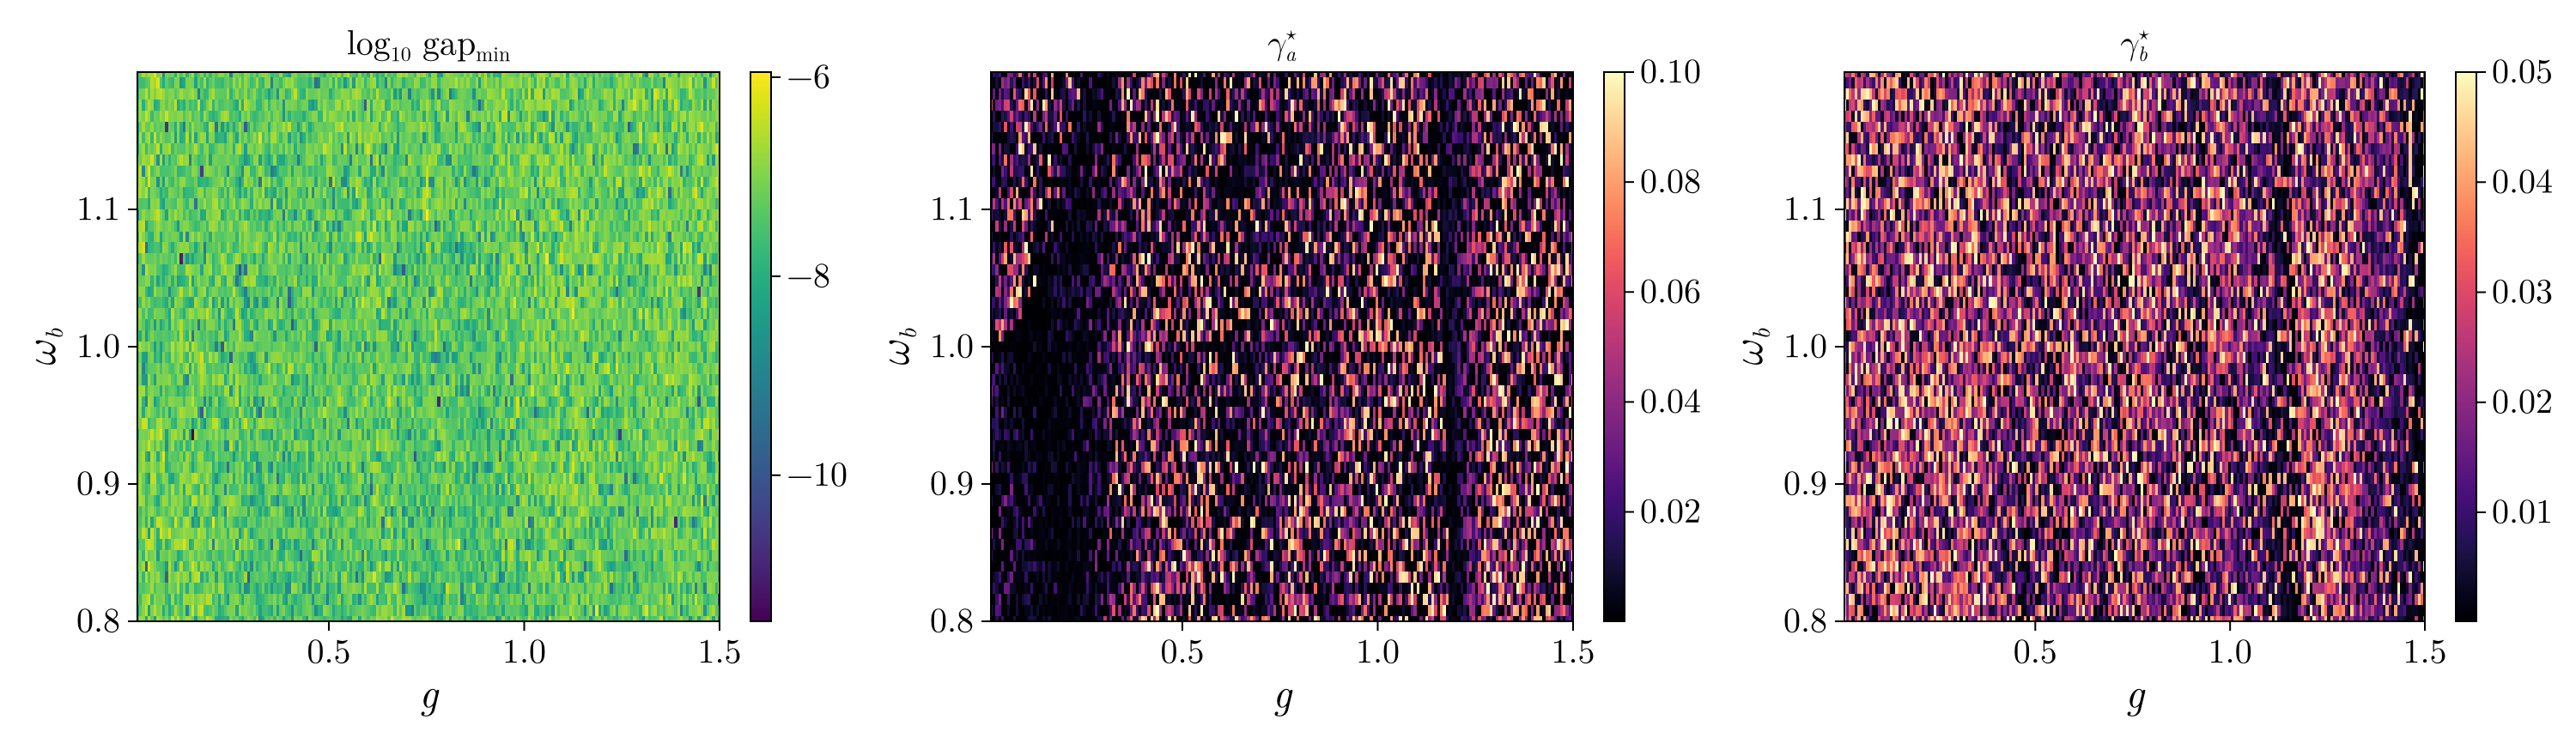

In [232]:
fig_4d